# Nanda Modular Addition AGOP Analysis

Comprehensive analysis of 20 completed Nanda experiments comparing:
- **Architectures**: MLP vs Transformer
- **Optimizers**: AdamW, Muon, SGD
- **Weight Decays**: 0.1, 1.0, 5.0, 10.0

This notebook analyzes:
1. Performance metrics (accuracy, grokking outcomes)
2. AGOP metric evolution and relationship to grokking
3. Statistical comparisons between conditions

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Import our analysis utilities
sys.path.append(str(Path.cwd()))
from analysis_utils import (
    load_all_experiments, generate_summary_table, classify_grokking,
    compute_time_to_grok, statistical_comparison, filter_experiments,
    plot_agop_comparison, create_comparison_heatmap, smooth_series,
    detect_phase_transitions, compute_correlation
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Paths
RESULTS_DIR = Path('../results/nanda')
FIGURES_DIR = Path('./figures/nanda')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {RESULTS_DIR.absolute()}")
print(f"Figures will be saved to: {FIGURES_DIR.absolute()}")

Results directory: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/../results/nanda
Figures will be saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/figures/nanda


## Load All Nanda Experiments

In [2]:
# Load all experiments
experiments = load_all_experiments(RESULTS_DIR)
print(f"Loaded {len(experiments)} experiments")

# Generate summary table
summary_df = generate_summary_table(experiments)
print(f"\nSummary of experiments:")
display(summary_df.sort_values(['architecture', 'optimizer', 'weight_decay']))

Loaded 24 experiments

Summary of experiments:


,experiment,architecture,optimizer,weight_decay,lr,final_test_acc,max_test_acc,final_train_acc,grokked,grok_epoch
0,nanda_mlp_adamw_wd0.1_seed42,mlp,adamw,0.1,0.001,0.006488,0.009173,1.000000,False,-1
1,nanda_mlp_adamw_wd1.0_seed42,mlp,adamw,1.0,0.001,0.962748,0.965432,1.000000,True,32900
3,nanda_mlp_adamw_wd5.0_seed42,mlp,adamw,5.0,0.001,0.001454,0.009061,0.722454,False,-1
2,nanda_mlp_adamw_wd10.0_seed42,mlp,adamw,10.0,0.001,0.000112,0.009061,0.160836,False,-1
4,nanda_mlp_muon_wd0.1_seed42,mlp,muon,0.1,0.001,0.000336,0.008950,1.000000,False,-1
5,nanda_mlp_muon_wd1.0_seed42,mlp,muon,1.0,0.001,0.000112,0.008950,0.406527,False,-1
7,nanda_mlp_muon_wd5.0_seed42,mlp,muon,5.0,0.001,0.031547,0.031547,0.646736,False,-1
6,nanda_mlp_muon_wd10.0_seed42,mlp,muon,10.0,0.001,0.247343,0.248014,0.780679,False,-1
8,nanda_mlp_sgd_wd0.1_seed42,mlp,sgd,0.1,0.001,0.007719,0.009397,0.011488,False,-1
9,nanda_mlp_sgd_wd1.0_seed42,mlp,sgd,1.0,0.001,0.007719,0.009061,0.011488,False,-1


## Quick Statistics

In [10]:
# Overall statistics
total = len(summary_df)
grokked = summary_df['grokked'].sum()
grok_rate = grokked / total * 100

print(f"="*80)
print(f"NANDA DATASET - OVERALL STATISTICS")
print(f"="*80)
print(f"Total experiments: {total}")
print(f"Grokked: {grokked} ({grok_rate:.1f}%)")
print(f"Failed to grok: {total - grokked} ({100-grok_rate:.1f}%)")
print()

# By architecture
print(f"By Architecture:")
print(f"-"*80)
for arch in summary_df['architecture'].unique():
    arch_df = summary_df[summary_df['architecture'] == arch]
    arch_grok = arch_df['grokked'].sum()
    arch_total = len(arch_df)
    print(f"  {arch.upper()}: {arch_grok}/{arch_total} grokked ({arch_grok/arch_total*100:.1f}%)")
print()

# By optimizer
print(f"By Optimizer:")
print(f"-"*80)
for opt in summary_df['optimizer'].unique():
    opt_df = summary_df[summary_df['optimizer'] == opt]
    opt_grok = opt_df['grokked'].sum()
    opt_total = len(opt_df)
    print(f"  {opt.upper()}: {opt_grok}/{opt_total} grokked ({opt_grok/opt_total*100:.1f}%)")

print(f"="*80)

# Store grok rate for later use
grok_rate_value = grok_rate

NANDA DATASET - OVERALL STATISTICS
Total experiments: 24
Grokked: 2 (8.3%)
Failed to grok: 22 (91.7%)

By Architecture:
--------------------------------------------------------------------------------
  MLP: 1/12 grokked (8.3%)
  TRANSFORMER: 1/12 grokked (8.3%)

By Optimizer:
--------------------------------------------------------------------------------
  ADAMW: 2/8 grokked (25.0%)
  MUON: 0/8 grokked (0.0%)
  SGD: 0/8 grokked (0.0%)


---
# Section 0: Training Dynamics - Accuracy and Loss Curves

**First Analytical Insight**: Visualize training and test accuracy/loss over epochs for all completed experiments. 
Red dashed vertical lines indicate the "grokking epoch" where test performance catches up with train performance.


In [15]:
def detect_grokking_epoch(train_acc, test_acc, grok_threshold=0.85, min_epoch=100):
    """
    Detect the epoch where grokking occurs (test accuracy exceeds threshold).
    
    Args:
        train_acc: Array of training accuracies (unused, kept for compatibility)
        test_acc: Array of test accuracies
        grok_threshold: Test accuracy threshold to define grokking (default 0.85)
        min_epoch: Minimum epoch to start checking (avoid early noise)
    
    Returns:
        Grokking epoch (int) or None if no grokking detected
    """
    if len(test_acc) < min_epoch:
        return None
    
    # Find the first epoch where test accuracy exceeds the grokking threshold
    for i in range(min_epoch, len(test_acc)):
        if test_acc[i] > grok_threshold:
            return i
    
    return None

print("Grokking detection function loaded.")
print(f"Grokking definition: test_acc > 0.85")


Grokking detection function loaded.
Grokking definition: test_acc > 0.85


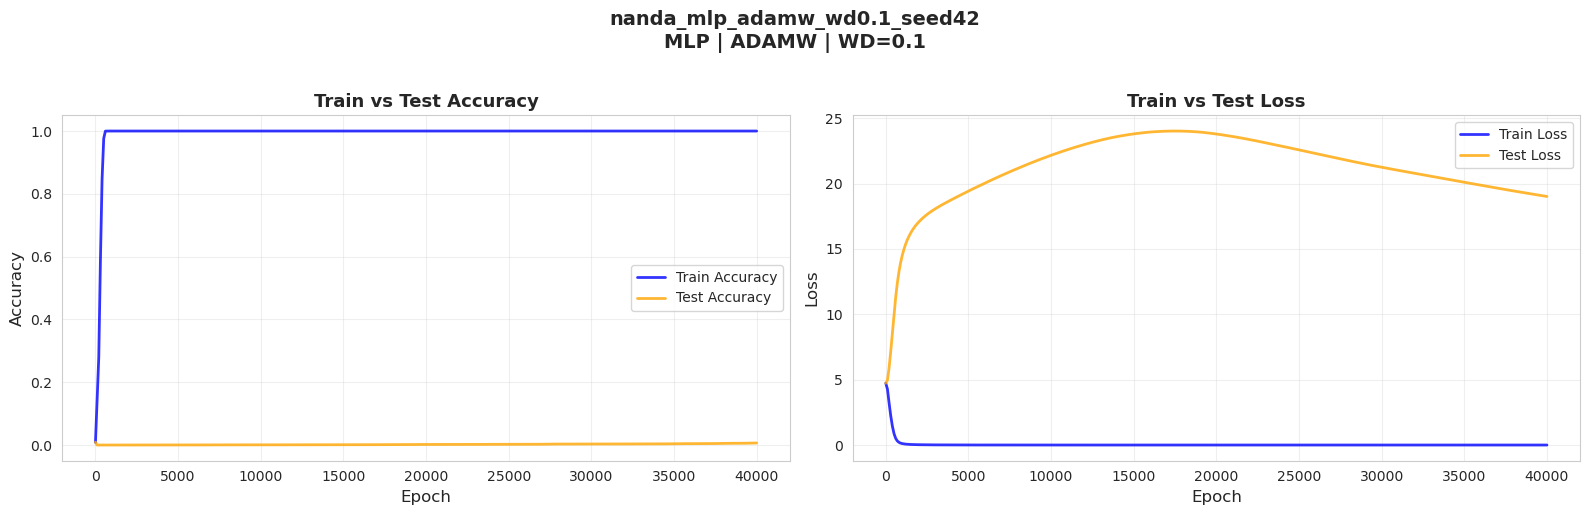

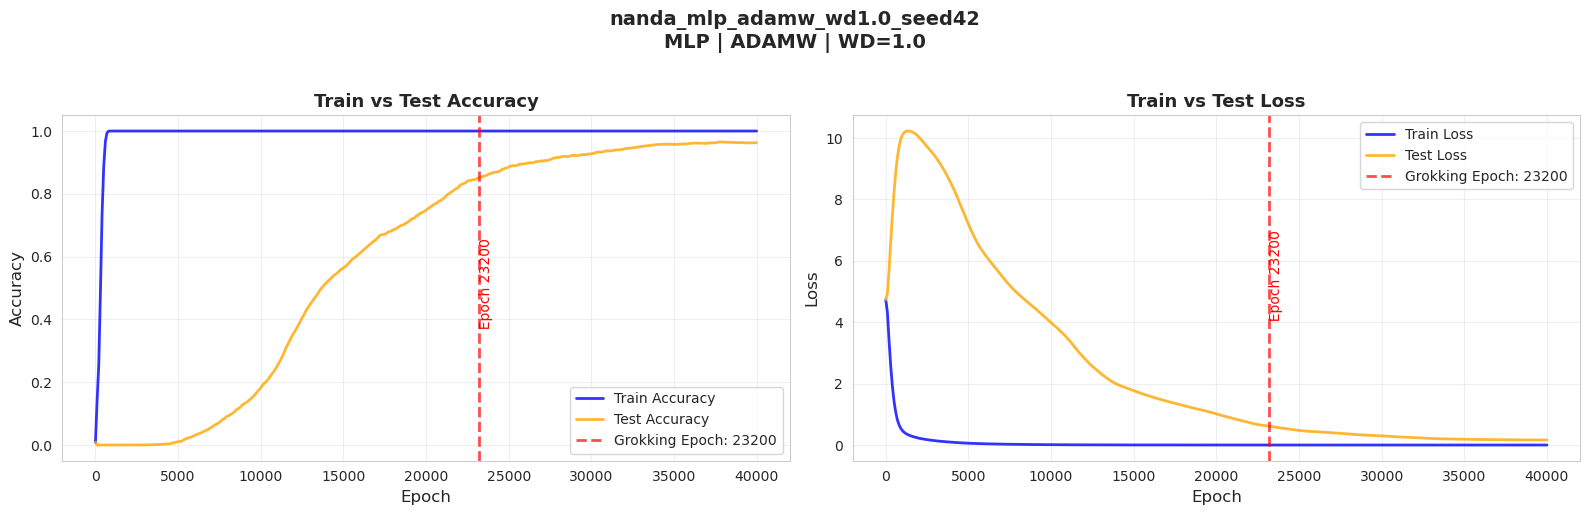

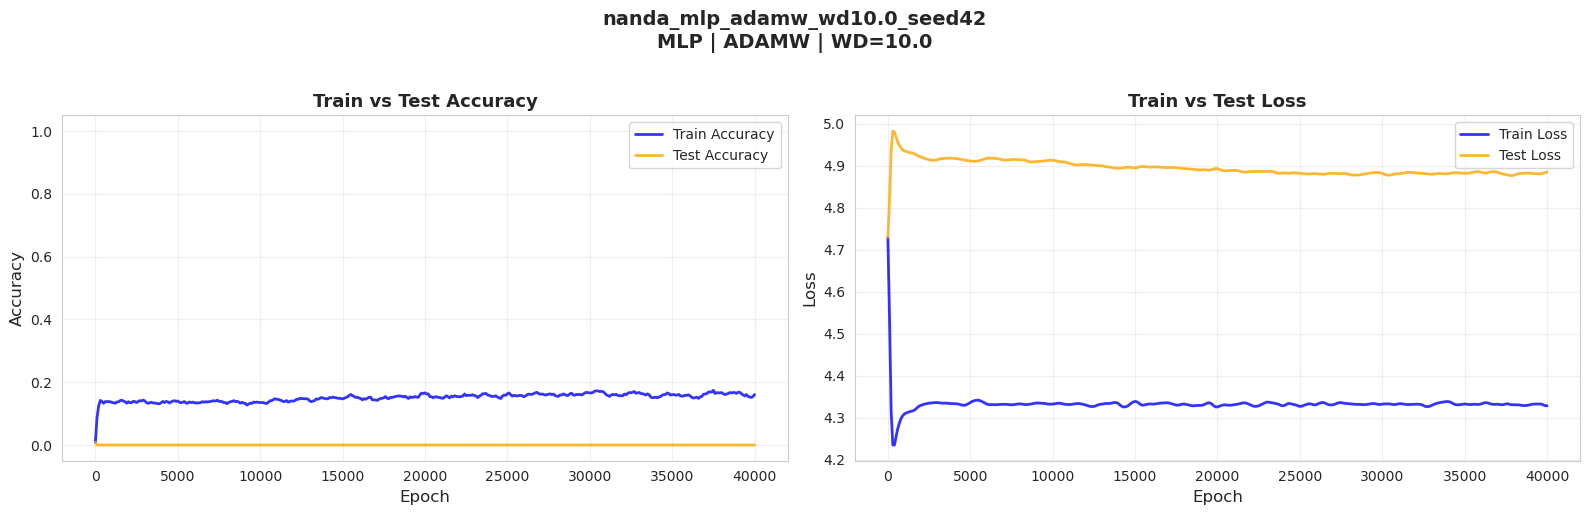

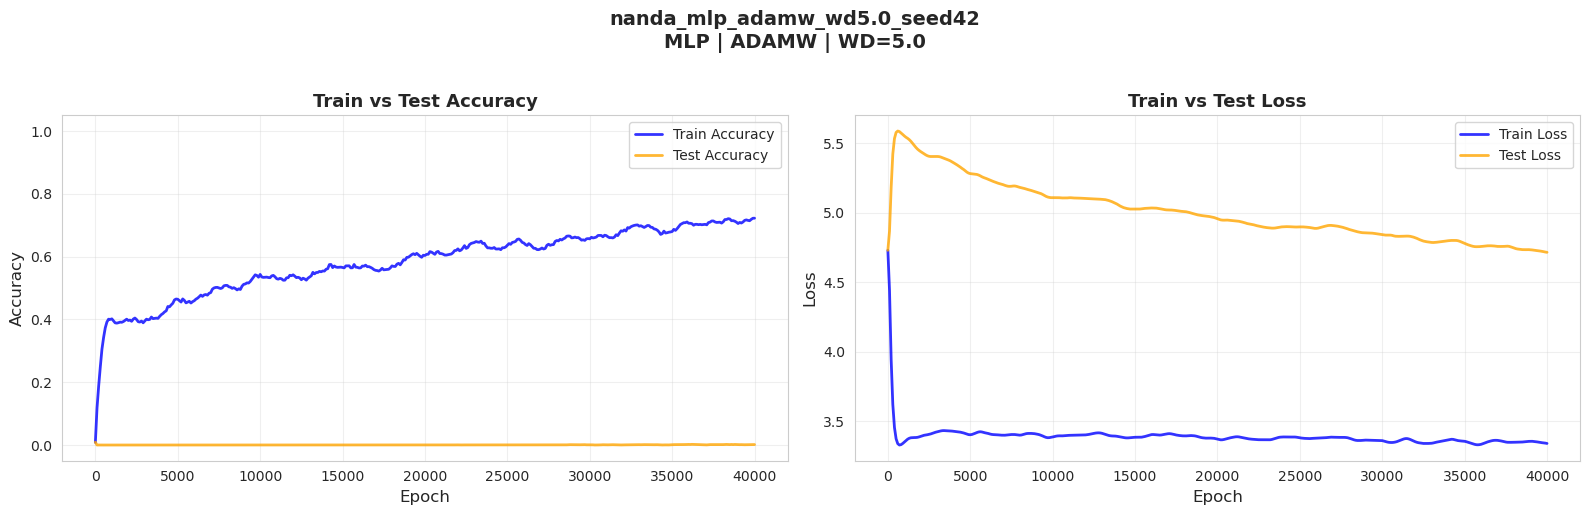

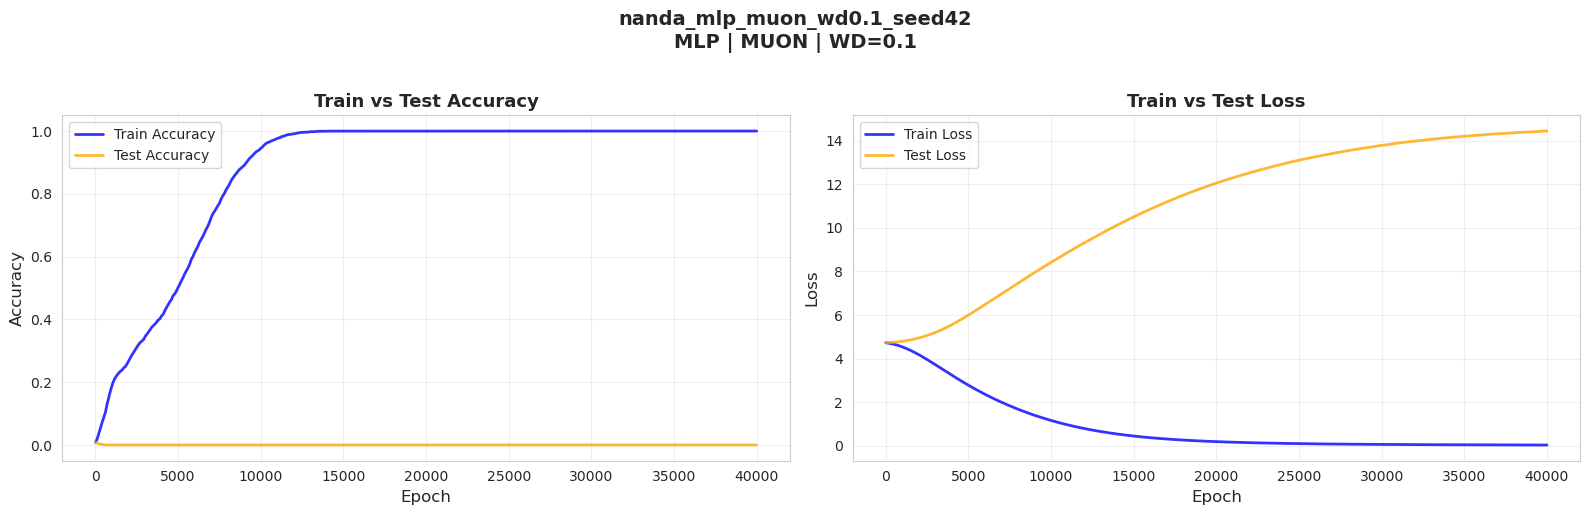

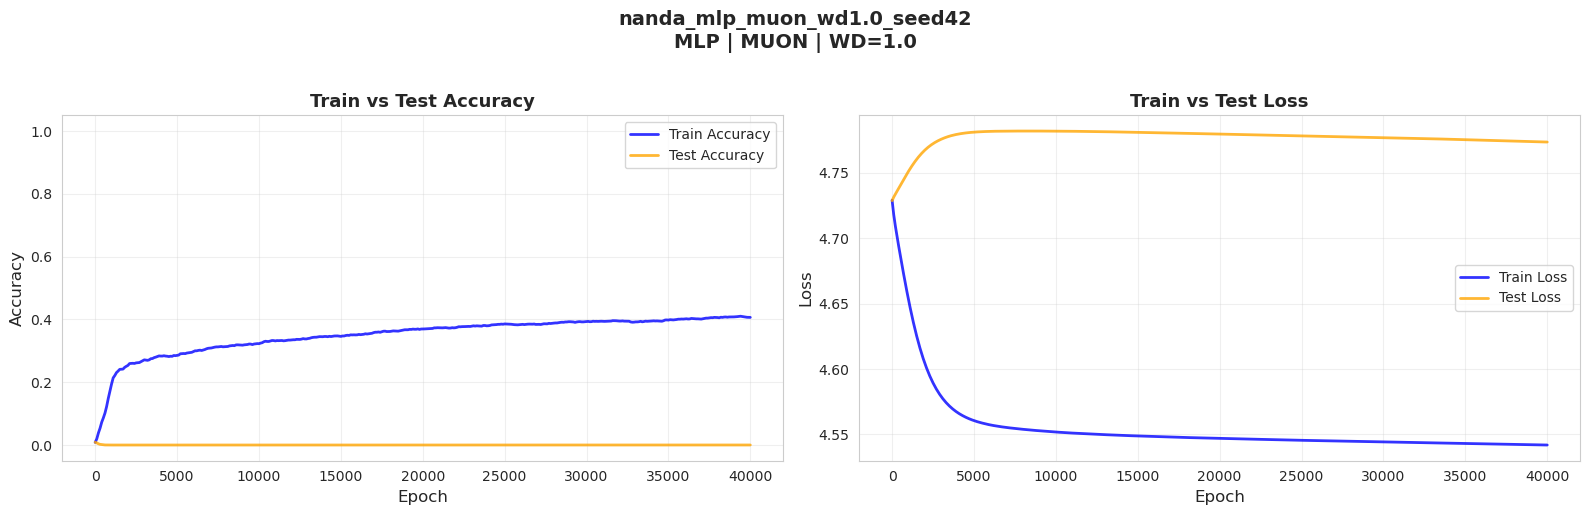

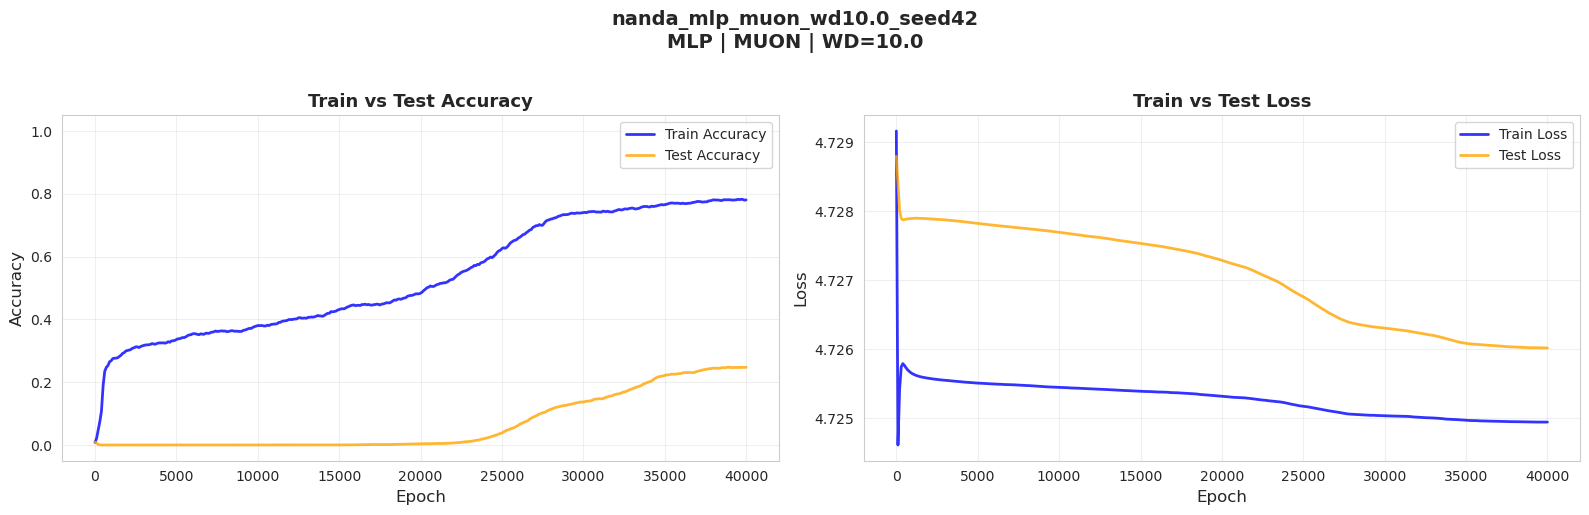

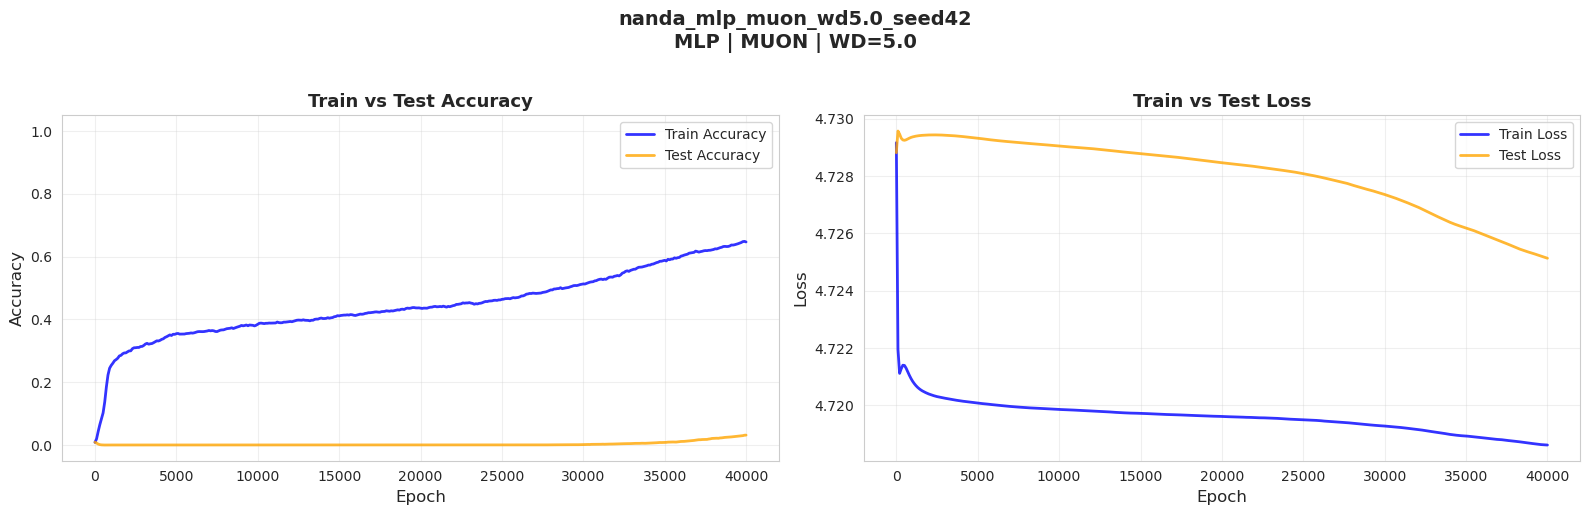

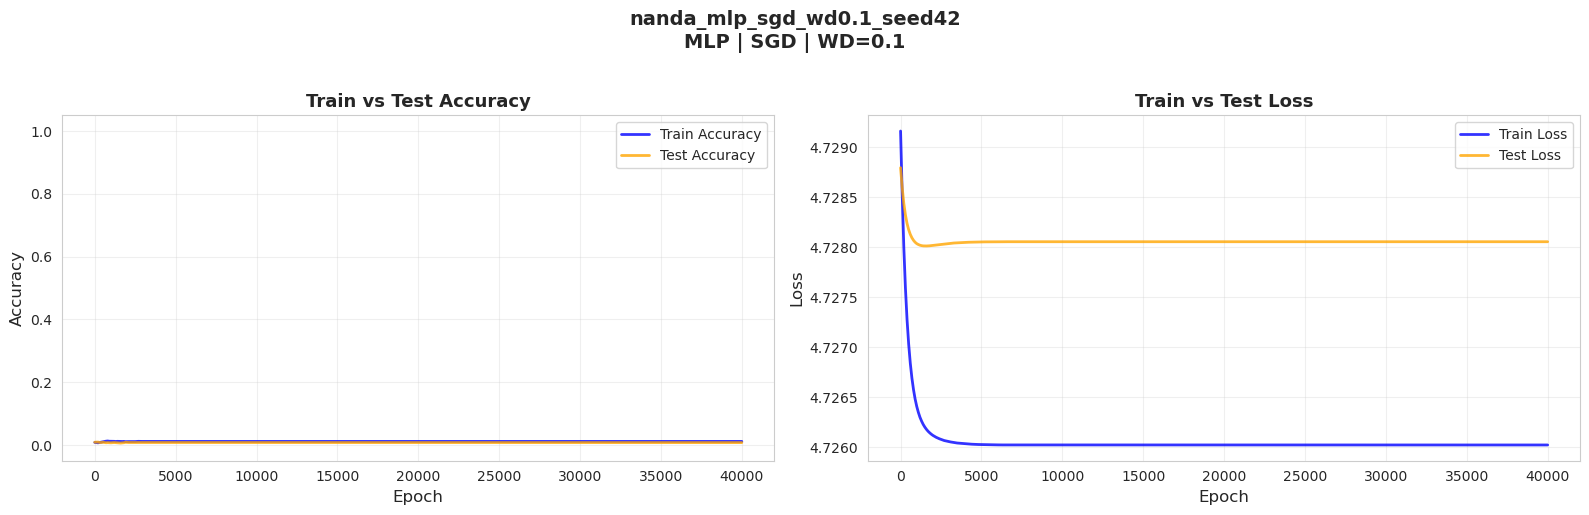

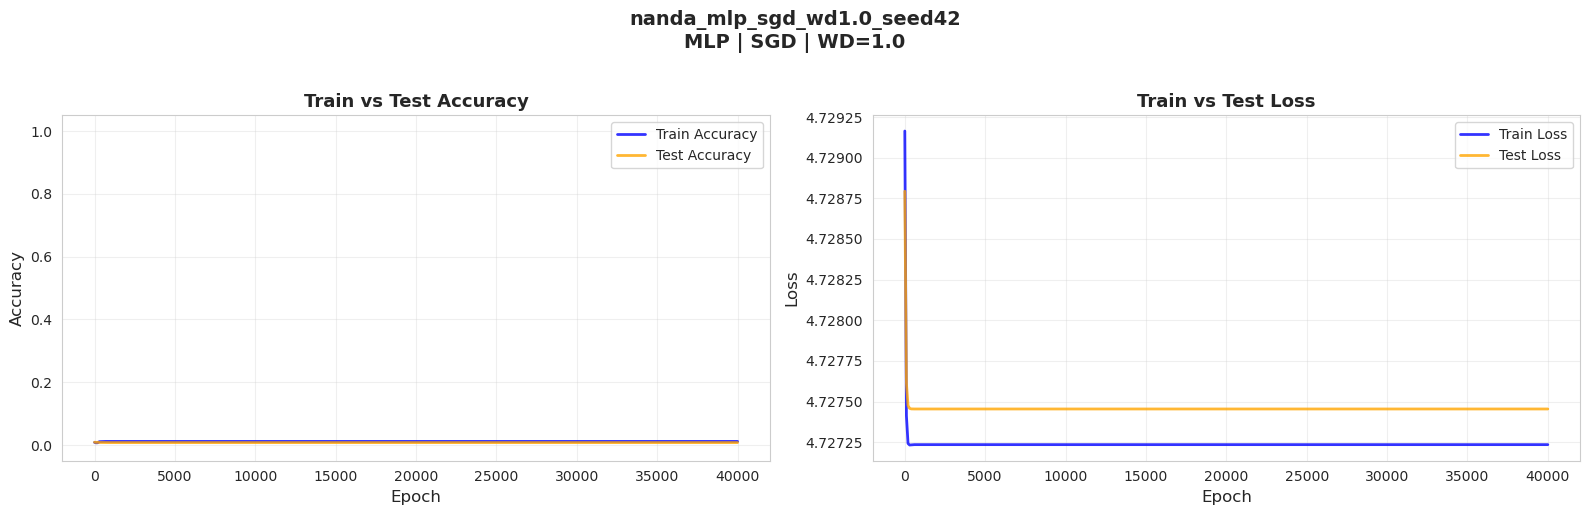

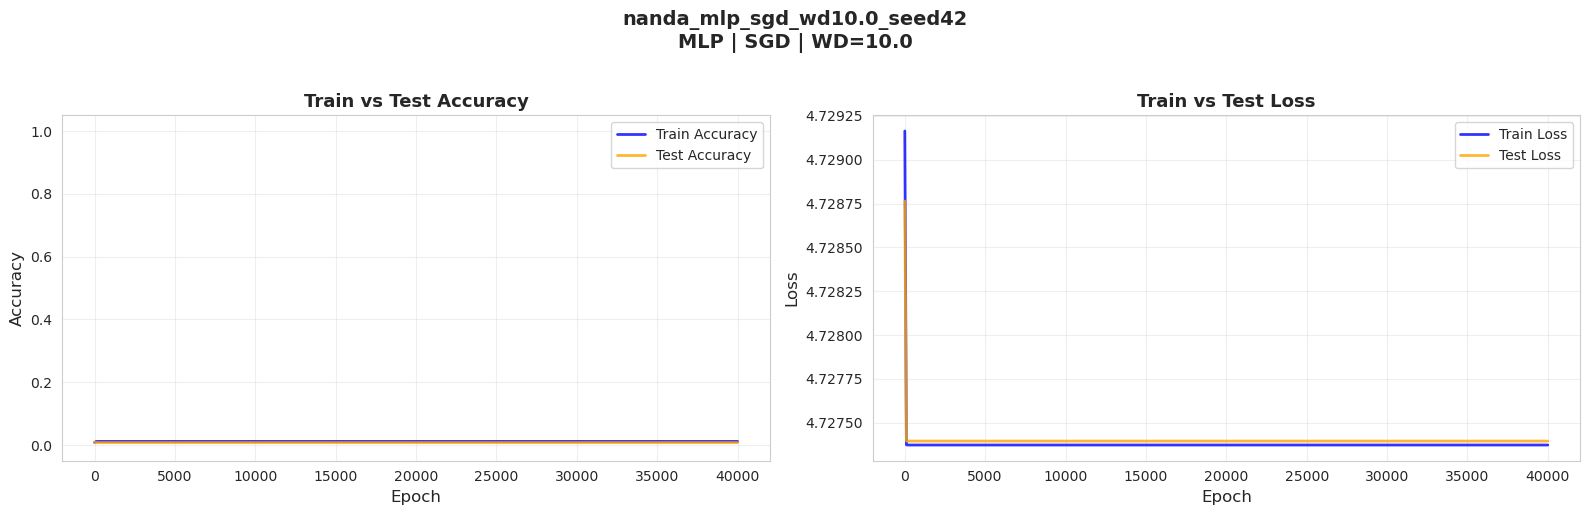

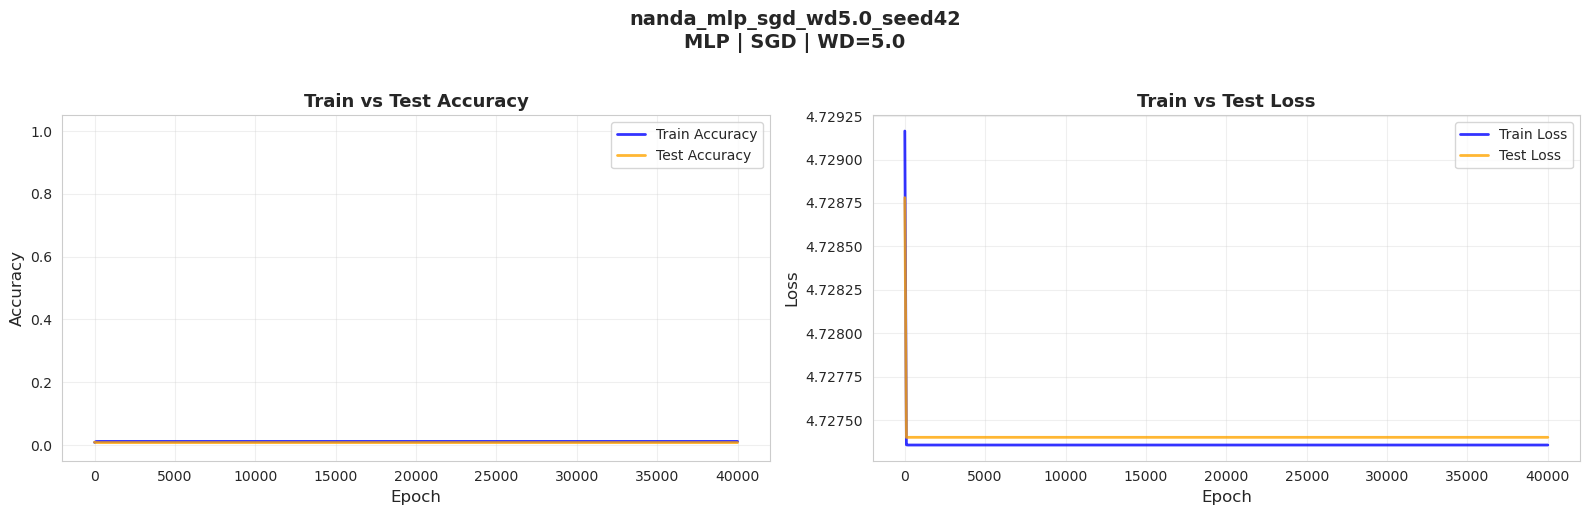

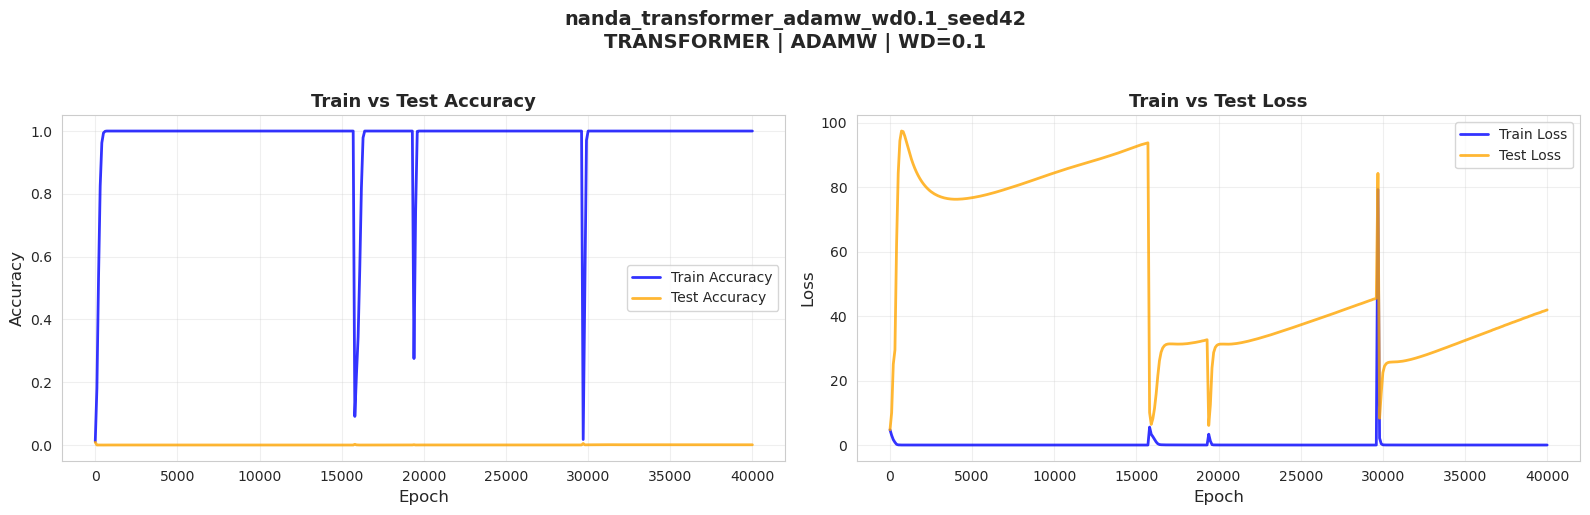

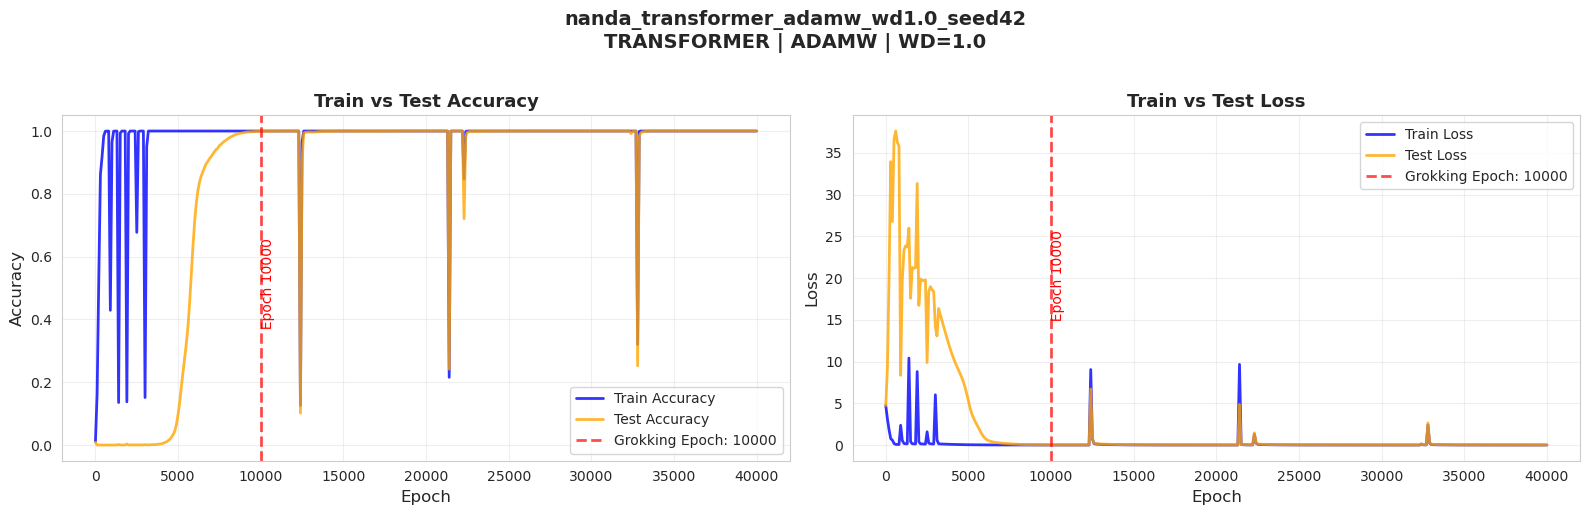

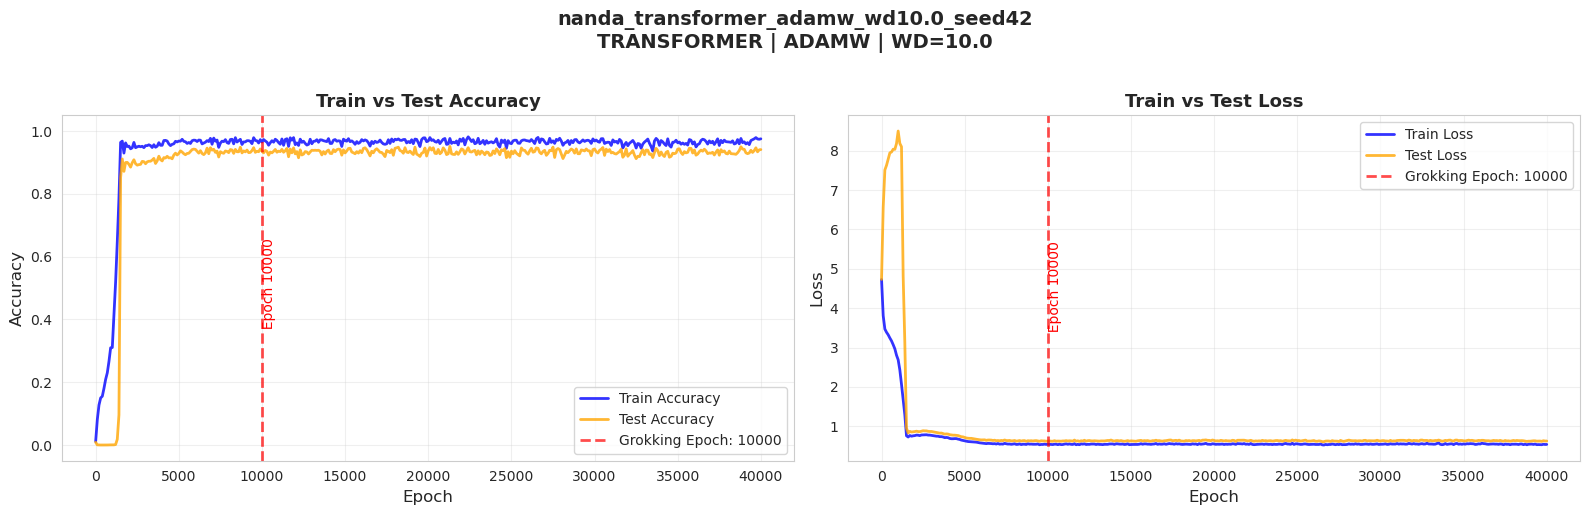

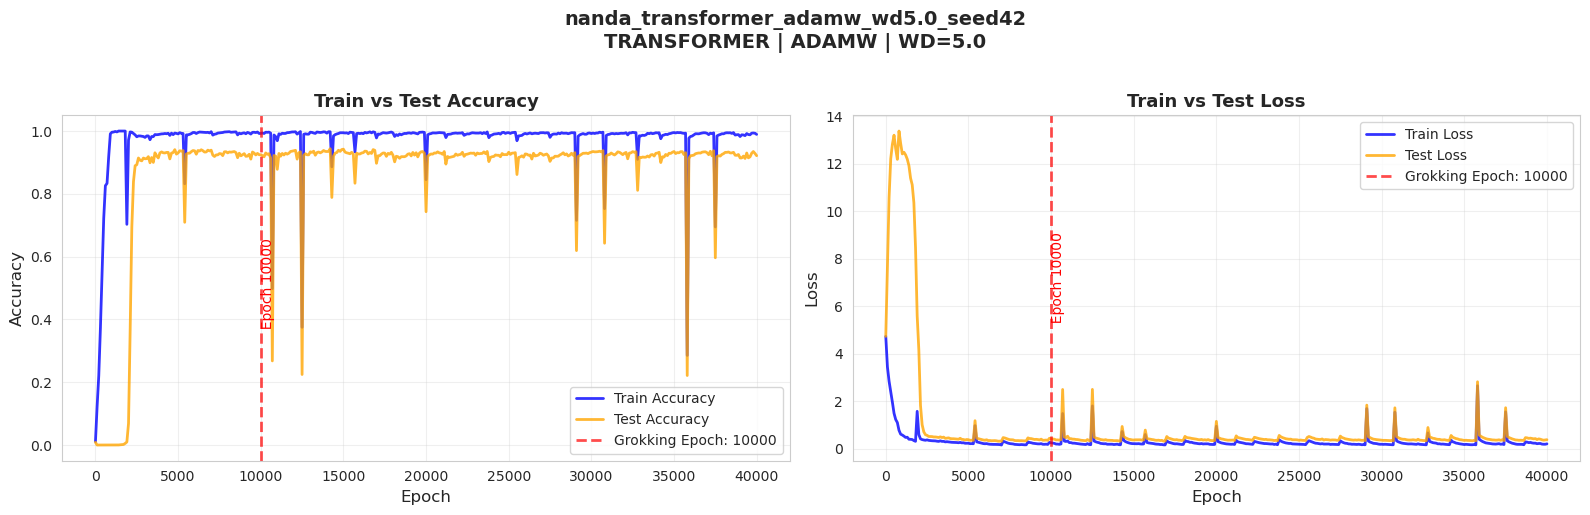

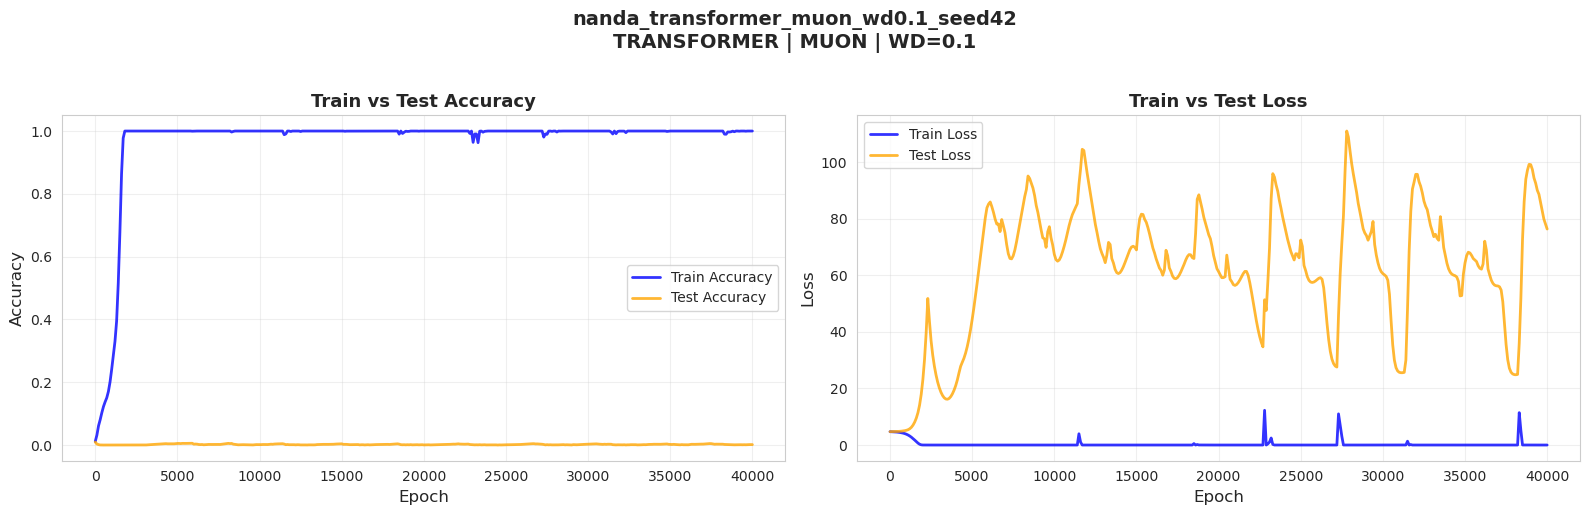

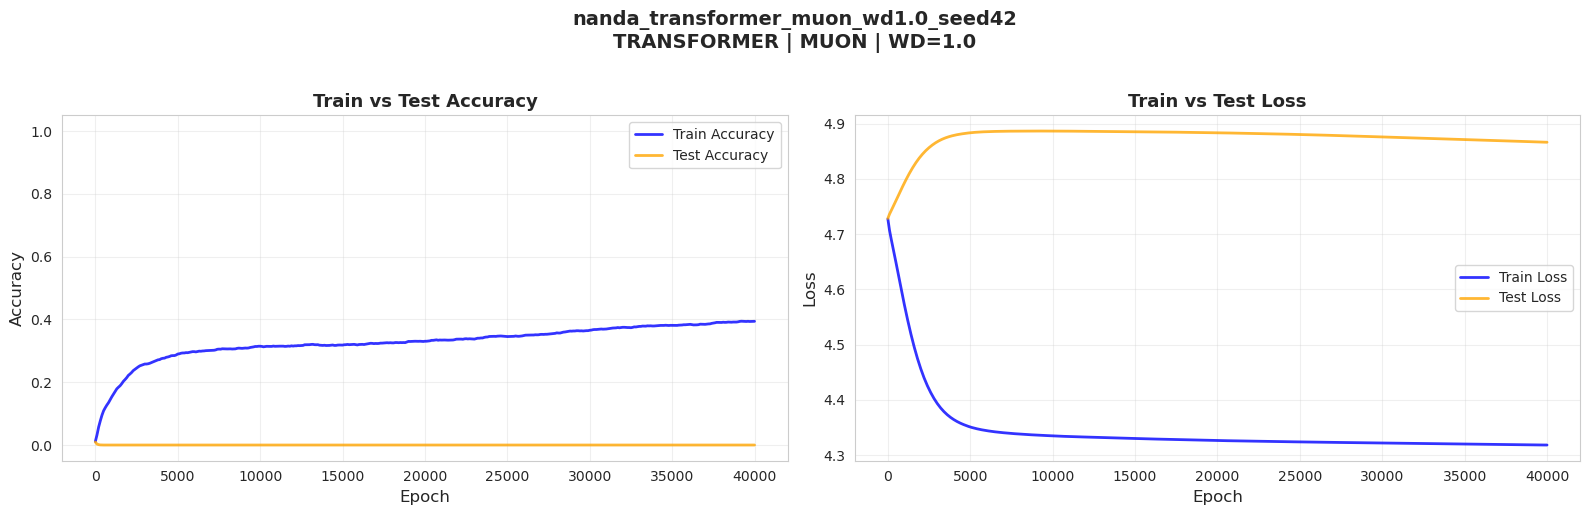

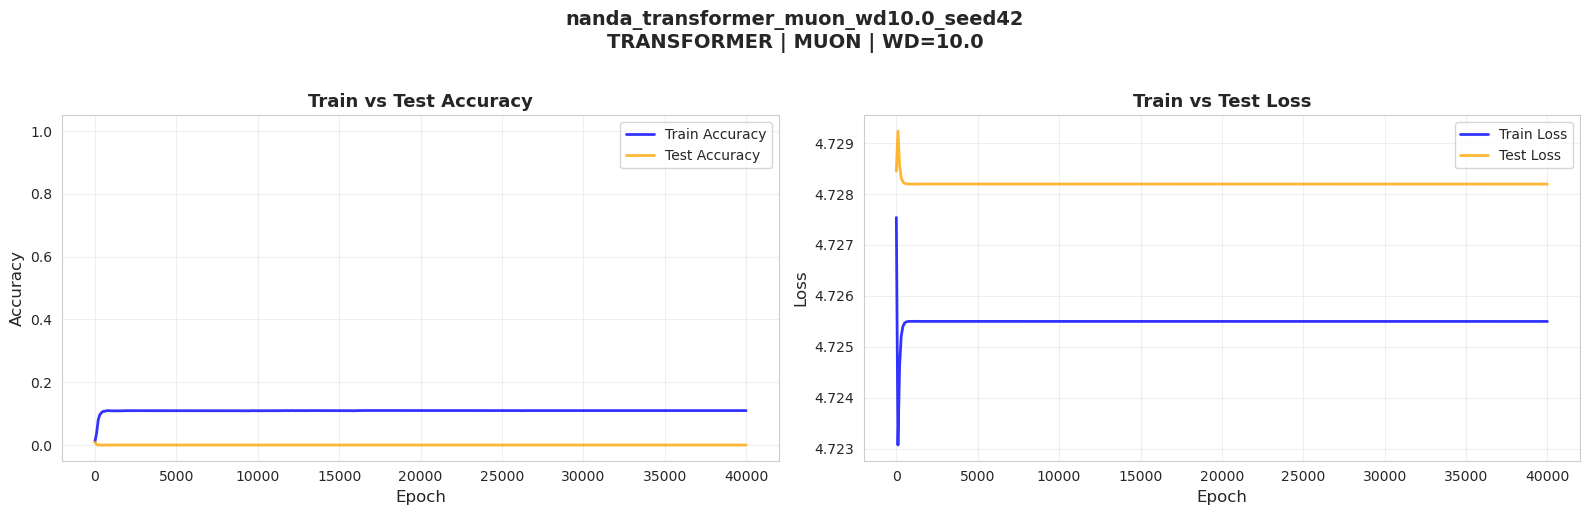

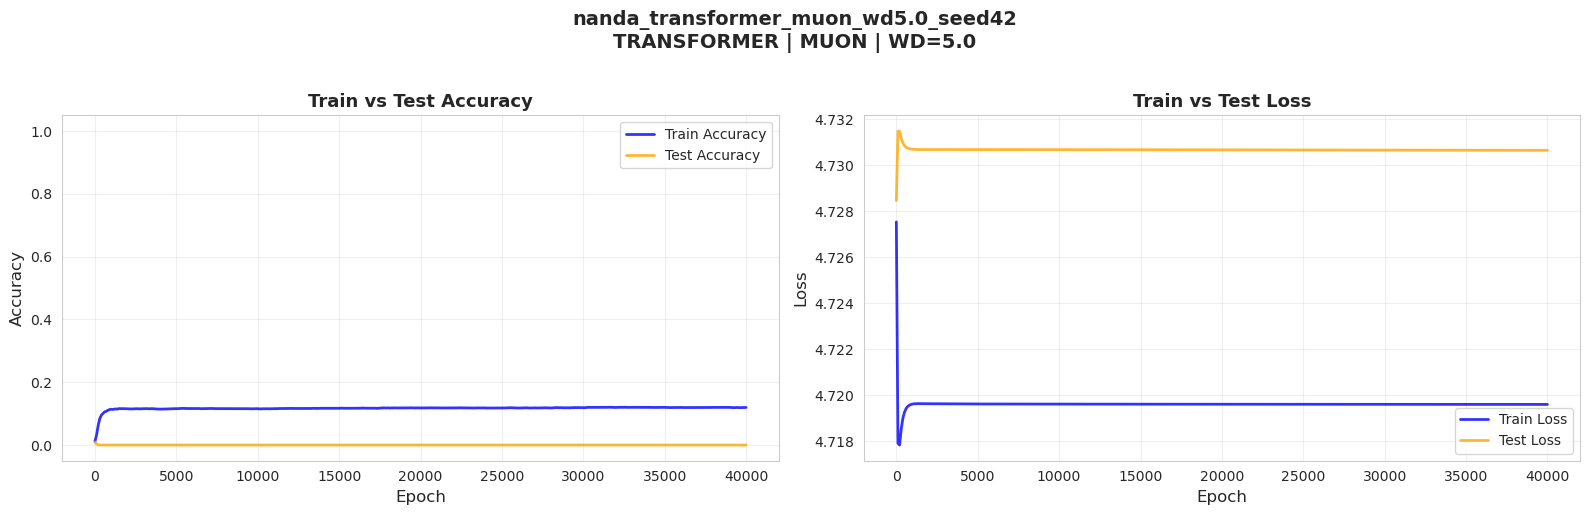

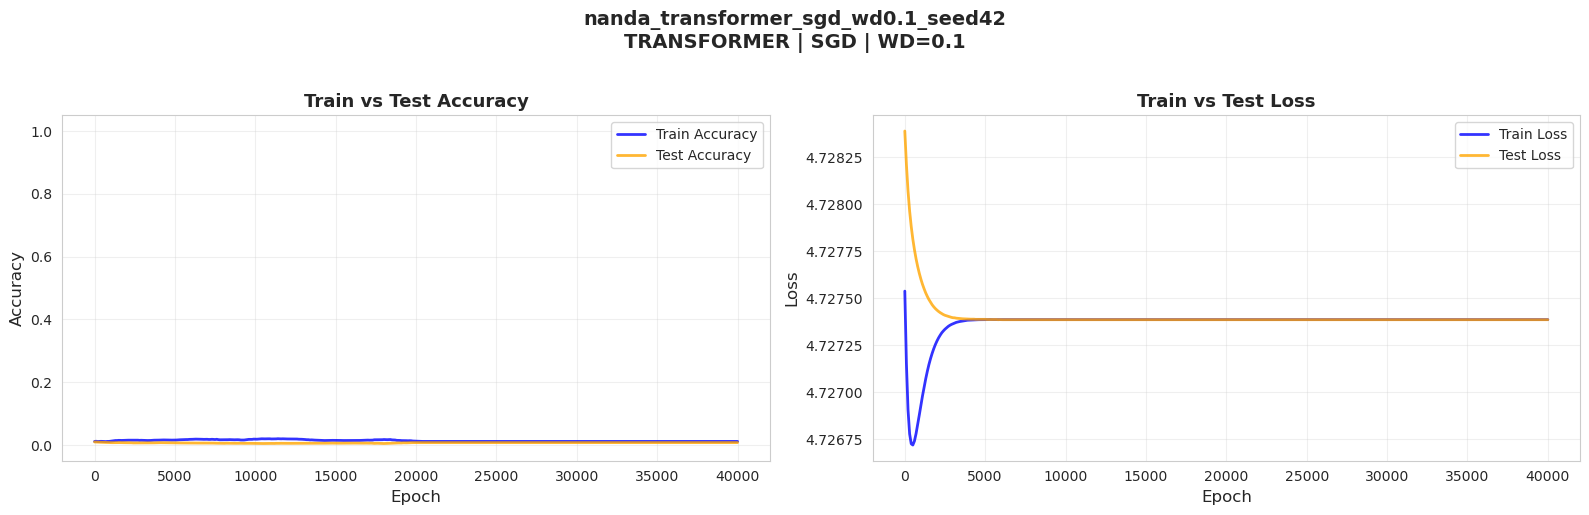

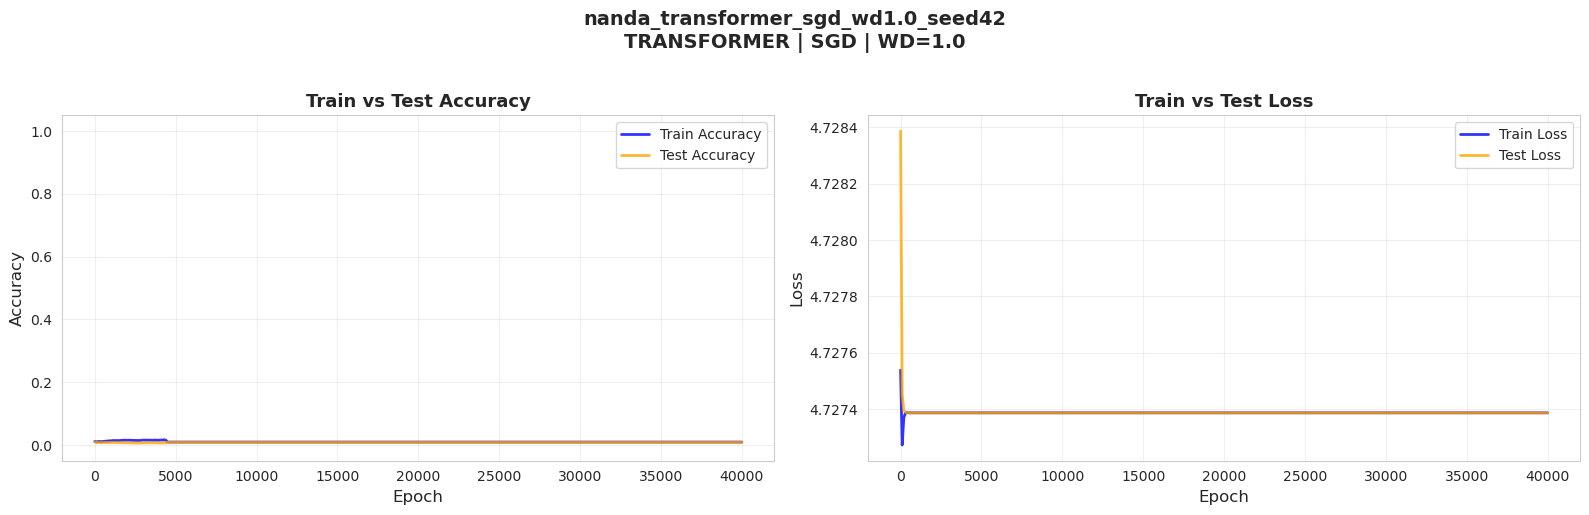

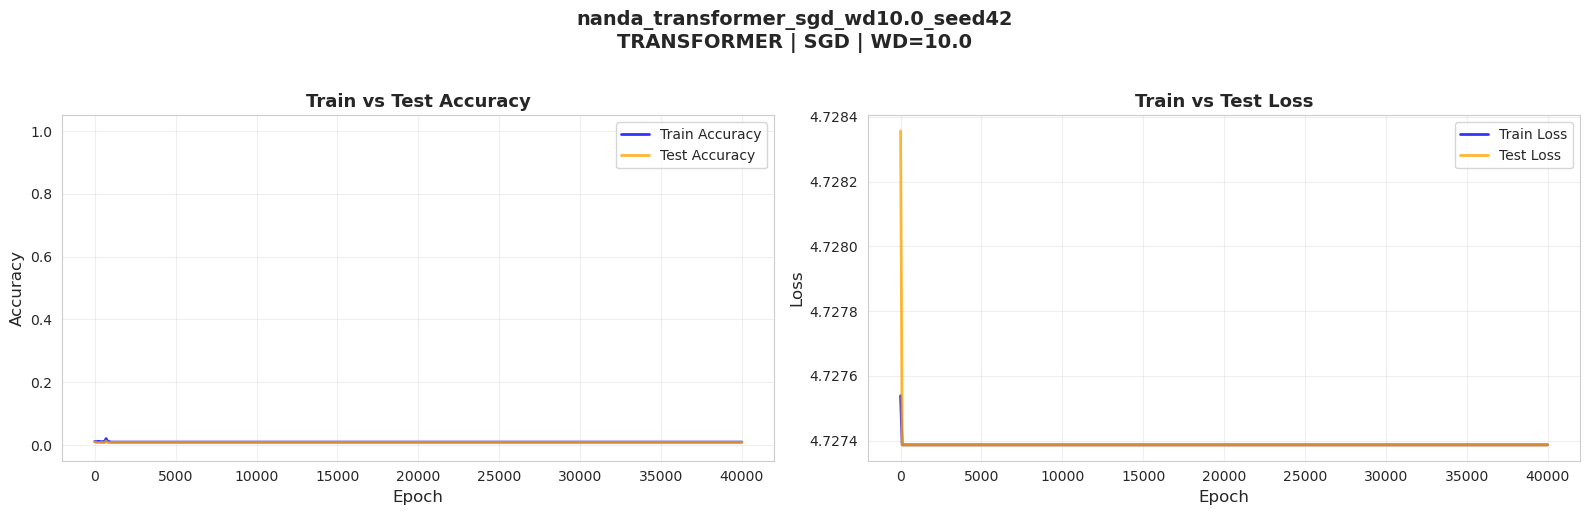

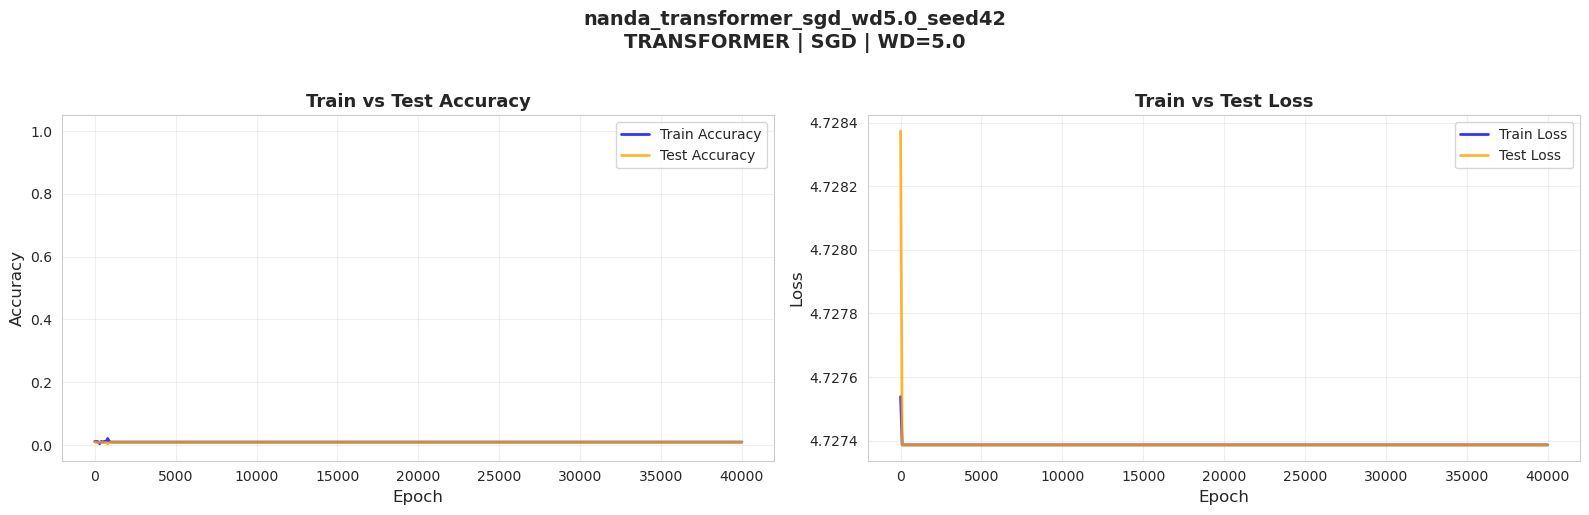


Generated 24 training dynamics plots
Saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/figures/nanda/training_dynamics


In [16]:
## Generate Training Dynamics Plots for All Experiments

# Create a subdirectory for training dynamics plots
TRAIN_DYNAMICS_DIR = FIGURES_DIR / 'training_dynamics'
TRAIN_DYNAMICS_DIR.mkdir(parents=True, exist_ok=True)

grokking_summary = []

for exp_name, exp_data in experiments.items():
    history = exp_data.get('history', {})
    config = exp_data.get('config', {})
    
    # Check if we have the required data
    required_keys = ['train_acc', 'test_acc', 'train_loss', 'test_loss']
    if not all(key in history for key in required_keys):
        print(f"Skipping {exp_name}: missing required metrics")
        continue
    
    # Extract data
    epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
    train_acc = np.array(history['train_acc'])
    test_acc = np.array(history['test_acc'])
    train_loss = np.array(history['train_loss'])
    test_loss = np.array(history['test_loss'])
    
    # Detect grokking epoch
    grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
    grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
    
    # Store summary
    grokking_summary.append({
        'experiment': exp_name,
        'architecture': config.get('architecture', 'unknown'),
        'optimizer': config.get('optimizer', 'unknown'),
        'weight_decay': config.get('weight_decay', 0),
        'grok_epoch': grok_epoch if grok_epoch else -1,
        'final_test_acc': test_acc[-1],
        'final_train_acc': train_acc[-1]
    })
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Plot 1: Accuracy
    ax1.plot(epochs, train_acc, 'b-', linewidth=2, label='Train Accuracy', alpha=0.8)
    ax1.plot(epochs, test_acc, 'orange', linewidth=2, label='Test Accuracy', alpha=0.8)
    
    if grok_epoch is not None:
        ax1.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, 
                   label=f'Grokking Epoch: {grok_epoch}', alpha=0.7)
        ax1.text(grok_epoch, 0.5, f'  Epoch {grok_epoch}', 
                rotation=90, verticalalignment='center', fontsize=10, color='red')
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title('Train vs Test Accuracy', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(alpha=0.3)
    ax1.set_ylim([-0.05, 1.05])
    
    # Plot 2: Loss
    ax2.plot(epochs, train_loss, 'b-', linewidth=2, label='Train Loss', alpha=0.8)
    ax2.plot(epochs, test_loss, 'orange', linewidth=2, label='Test Loss', alpha=0.8)
    
    if grok_epoch is not None:
        ax2.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, 
                   label=f'Grokking Epoch: {grok_epoch}', alpha=0.7)
        ax2.text(grok_epoch, ax2.get_ylim()[1] * 0.5, f'  Epoch {grok_epoch}', 
                rotation=90, verticalalignment='center', fontsize=10, color='red')
    
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Train vs Test Loss', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10, loc='best')
    ax2.grid(alpha=0.3)
    
    # Overall title
    arch = config.get('architecture', 'unknown')
    opt = config.get('optimizer', 'unknown')
    wd = config.get('weight_decay', 0)
    fig.suptitle(f'{exp_name}\n{arch.upper()} | {opt.upper()} | WD={wd}', 
                fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    # Save figure
    safe_name = exp_name.replace('/', '_').replace(' ', '_')
    plt.savefig(TRAIN_DYNAMICS_DIR / f'{safe_name}_dynamics.png', dpi=300, bbox_inches='tight')
    
    # Display inline for interactive analysis
    plt.show()
    plt.close()

print(f"\n{'='*80}")
print(f"Generated {len(grokking_summary)} training dynamics plots")
print(f"Saved to: {TRAIN_DYNAMICS_DIR.absolute()}")
print(f"{'='*80}")


In [17]:
## Summary: Detected Grokking Epochs

# Create DataFrame from summary
grok_summary_df = pd.DataFrame(grokking_summary)
grok_summary_df = grok_summary_df.sort_values(['architecture', 'optimizer', 'weight_decay'])

print(f"\nGrokking Detection Summary:")
print(f"{'='*80}")
print(f"Total experiments analyzed: {len(grok_summary_df)}")
print(f"Experiments with detected grokking: {(grok_summary_df['grok_epoch'] > 0).sum()}")
print(f"{'='*80}\n")

# Show only experiments that grokked
grokked_df = grok_summary_df[grok_summary_df['grok_epoch'] > 0].copy()
if len(grokked_df) > 0:
    print(f"\nExperiments with Detected Grokking:")
    print(f"{'-'*80}")
    display(grokked_df[['experiment', 'architecture', 'optimizer', 'weight_decay', 
                        'grok_epoch', 'final_test_acc', 'final_train_acc']])
else:
    print("\nNo grokking detected in any experiment with current threshold settings.")

# Show full summary table
print(f"\n\nFull Summary (all experiments):")
print(f"{'-'*80}")
display(grok_summary_df[['experiment', 'architecture', 'optimizer', 'weight_decay', 
                         'grok_epoch', 'final_test_acc', 'final_train_acc']])



Grokking Detection Summary:
Total experiments analyzed: 24
Experiments with detected grokking: 4


Experiments with Detected Grokking:
--------------------------------------------------------------------------------


,experiment,architecture,optimizer,weight_decay,grok_epoch,final_test_acc,final_train_acc
1,nanda_mlp_adamw_wd1.0_seed42,mlp,adamw,1.0,23200,0.962748,1.000000
13,nanda_transformer_adamw_wd1.0_seed42,transformer,adamw,1.0,10000,1.000000,1.000000
15,nanda_transformer_adamw_wd5.0_seed42,transformer,adamw,5.0,10000,0.921468,0.989295
14,nanda_transformer_adamw_wd10.0_seed42,transformer,adamw,10.0,10000,0.940933,0.975196




Full Summary (all experiments):
--------------------------------------------------------------------------------


,experiment,architecture,optimizer,weight_decay,grok_epoch,final_test_acc,final_train_acc
0,nanda_mlp_adamw_wd0.1_seed42,mlp,adamw,0.1,-1,0.006488,1.000000
1,nanda_mlp_adamw_wd1.0_seed42,mlp,adamw,1.0,23200,0.962748,1.000000
3,nanda_mlp_adamw_wd5.0_seed42,mlp,adamw,5.0,-1,0.001454,0.722454
2,nanda_mlp_adamw_wd10.0_seed42,mlp,adamw,10.0,-1,0.000112,0.160836
4,nanda_mlp_muon_wd0.1_seed42,mlp,muon,0.1,-1,0.000336,1.000000
5,nanda_mlp_muon_wd1.0_seed42,mlp,muon,1.0,-1,0.000112,0.406527
7,nanda_mlp_muon_wd5.0_seed42,mlp,muon,5.0,-1,0.031547,0.646736
6,nanda_mlp_muon_wd10.0_seed42,mlp,muon,10.0,-1,0.247343,0.780679
8,nanda_mlp_sgd_wd0.1_seed42,mlp,sgd,0.1,-1,0.007719,0.011488
9,nanda_mlp_sgd_wd1.0_seed42,mlp,sgd,1.0,-1,0.007719,0.011488


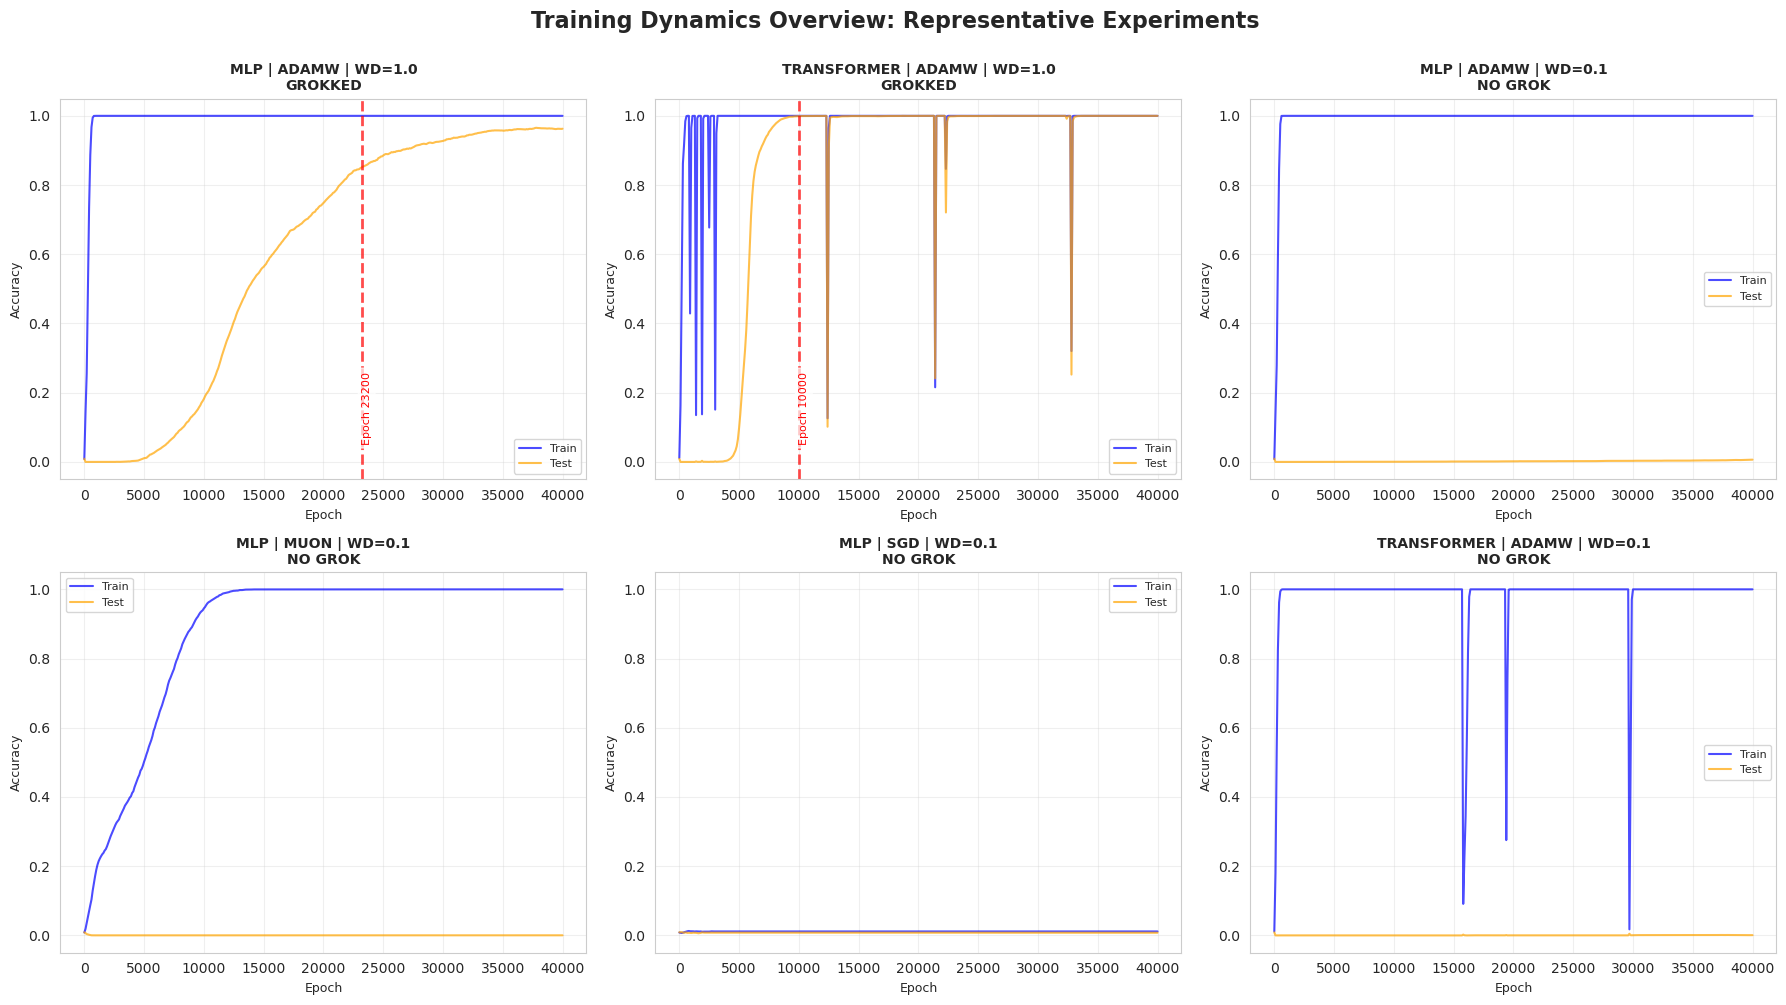

Saved overview figure: training_dynamics_overview.png


In [18]:
## Create Combined Overview Plot

# Select representative experiments: grokked and non-grokked
exp_to_plot = []

# Get grokked experiments
if len(grokked_df) > 0:
    for _, row in grokked_df.head(2).iterrows():
        exp_to_plot.append(row['experiment'])

# Get some non-grokked experiments from different configurations
non_grok_df = grok_summary_df[grok_summary_df['grok_epoch'] <= 0]
if len(non_grok_df) > 0:
    # Try to get diverse non-grokked examples
    for arch in ['mlp', 'transformer']:
        for opt in ['adamw', 'muon', 'sgd']:
            subset = non_grok_df[(non_grok_df['architecture'] == arch) & 
                                 (non_grok_df['optimizer'] == opt)]
            if len(subset) > 0:
                exp_to_plot.append(subset.iloc[0]['experiment'])
                if len(exp_to_plot) >= 6:
                    break
        if len(exp_to_plot) >= 6:
            break

# Limit to 6 plots for readability
exp_to_plot = exp_to_plot[:6]

if len(exp_to_plot) > 0:
    n_plots = len(exp_to_plot)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for idx, exp_name in enumerate(exp_to_plot):
        ax = axes[idx]
        exp_data = experiments[exp_name]
        history = exp_data['history']
        config = exp_data['config']
        
        epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
        train_acc = np.array(history['train_acc'])
        test_acc = np.array(history['test_acc'])
        
        # Detect grokking
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        
        # Plot
        ax.plot(epochs, train_acc, 'b-', linewidth=1.5, label='Train', alpha=0.7)
        ax.plot(epochs, test_acc, 'orange', linewidth=1.5, label='Test', alpha=0.7)
        
        if grok_epoch is not None:
            ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2, alpha=0.7)
            ax.text(grok_epoch, 0.05, f'Epoch {grok_epoch}', 
                   rotation=90, verticalalignment='bottom', fontsize=8, color='red',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        
        # Title
        arch = config.get('architecture', 'unknown')
        opt = config.get('optimizer', 'unknown')
        wd = config.get('weight_decay', 0)
        status = "GROKKED" if grok_epoch else "NO GROK"
        ax.set_title(f'{arch.upper()} | {opt.upper()} | WD={wd}\n{status}', 
                    fontsize=10, fontweight='bold')
        
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Accuracy', fontsize=9)
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)
        ax.set_ylim([-0.05, 1.05])
    
    # Hide unused subplots
    for idx in range(len(exp_to_plot), len(axes)):
        axes[idx].axis('off')
    
    fig.suptitle('Training Dynamics Overview: Representative Experiments', 
                fontsize=16, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'training_dynamics_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Saved overview figure: training_dynamics_overview.png")
else:
    print("No experiments to plot.")


## Focused Analysis: Transformer + AdamW Grokking Pattern

Deep dive into the only configuration that achieves grokking: Transformers with AdamW optimizer.
We'll examine how weight decay affects the grokking phenomenon.


Transformer + AdamW experiments: 4


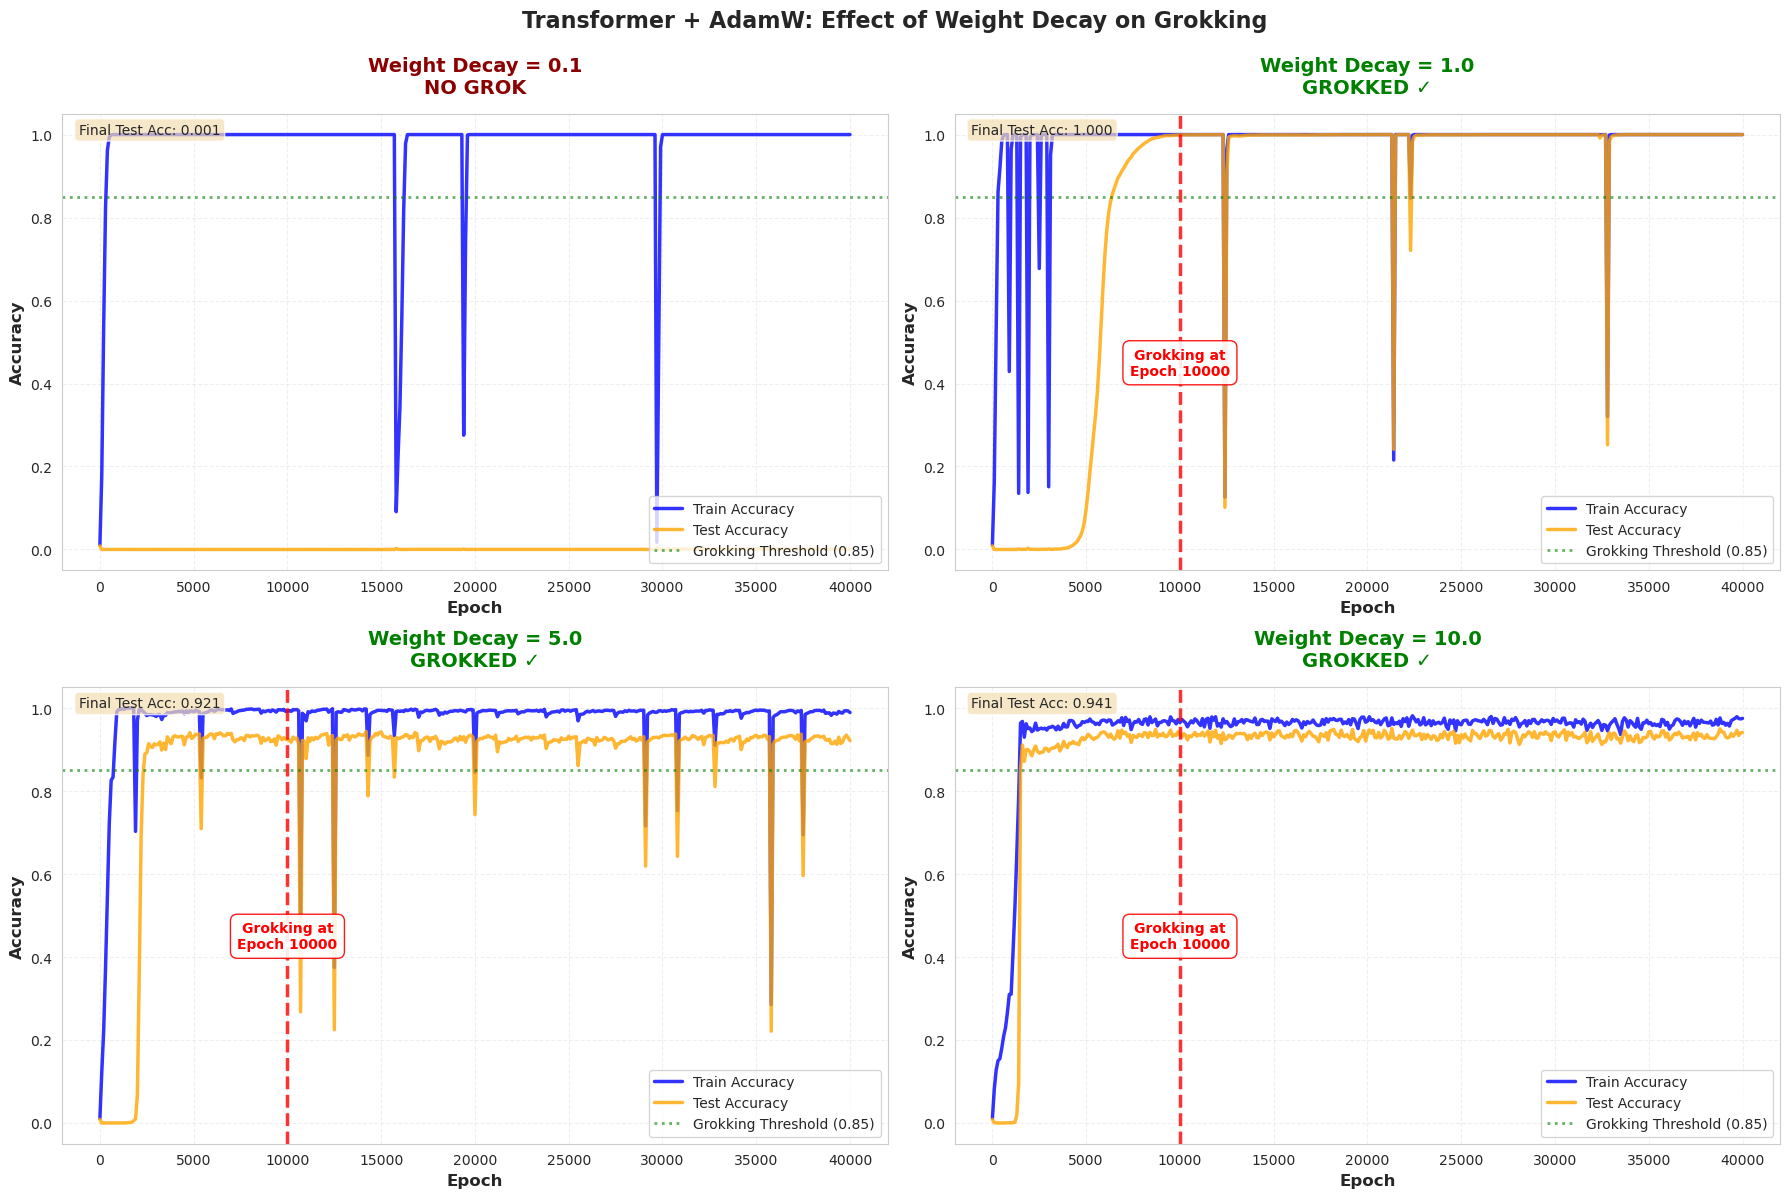


Grokking Summary for Transformer + AdamW:
WD= 0.1: NO GROK              | Final test acc: 0.0008
WD= 1.0: GROKKED at epoch 10000 | Final test acc: 1.0000
WD= 5.0: GROKKED at epoch 10000 | Final test acc: 0.9215
WD=10.0: GROKKED at epoch 10000 | Final test acc: 0.9409


In [19]:
# Filter for Transformer + AdamW experiments
transformer_adamw_exps = {name: data for name, data in experiments.items() 
                          if data['config'].get('architecture') == 'transformer' 
                          and data['config'].get('optimizer') == 'adamw'}

print(f"Transformer + AdamW experiments: {len(transformer_adamw_exps)}")

# Sort by weight decay
sorted_exps = sorted(transformer_adamw_exps.items(), 
                     key=lambda x: x[1]['config'].get('weight_decay', 0))

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (exp_name, exp_data) in enumerate(sorted_exps):
    if idx >= 4:  # Only show 4 weight decay values
        break
    
    ax = axes[idx]
    history = exp_data['history']
    config = exp_data['config']
    
    # Get data
    epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
    train_acc = np.array(history['train_acc'])
    test_acc = np.array(history['test_acc'])
    
    # Detect grokking
    grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
    grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
    
    # Plot accuracy curves
    ax.plot(epochs, train_acc, 'b-', linewidth=2.5, label='Train Accuracy', alpha=0.8)
    ax.plot(epochs, test_acc, 'orange', linewidth=2.5, label='Test Accuracy', alpha=0.8)
    
    # Add grokking threshold line
    ax.axhline(y=0.85, color='green', linestyle=':', linewidth=2, alpha=0.6, label='Grokking Threshold (0.85)')
    
    # Mark grokking epoch
    if grok_epoch is not None:
        ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2.5, alpha=0.8)
        ax.text(grok_epoch, 0.45, f'Grokking at\nEpoch {grok_epoch}', 
               rotation=0, verticalalignment='center', horizontalalignment='center',
               fontsize=10, color='red', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='red', alpha=0.9))
        status = "GROKKED ✓"
        title_color = 'green'
    else:
        status = "NO GROK"
        title_color = 'darkred'
    
    # Formatting
    wd = config.get('weight_decay', 0)
    ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title(f'Weight Decay = {wd}\n{status}', 
                fontsize=14, fontweight='bold', color=title_color, pad=15)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_ylim([-0.05, 1.05])
    
    # Add final test accuracy annotation
    final_test_acc = test_acc[-1]
    ax.text(0.02, 0.98, f'Final Test Acc: {final_test_acc:.3f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

fig.suptitle('Transformer + AdamW: Effect of Weight Decay on Grokking', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transformer_adamw_weight_decay_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGrokking Summary for Transformer + AdamW:")
print("="*80)
for exp_name, exp_data in sorted_exps:
    wd = exp_data['config'].get('weight_decay', 0)
    history = exp_data['history']
    test_acc = np.array(history['test_acc'])
    train_acc = np.array(history['train_acc'])
    
    grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
    epochs = np.array(history.get('epoch', range(len(test_acc))))
    grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
    
    final_test = test_acc[-1]
    final_train = train_acc[-1]
    
    if grok_epoch:
        print(f"WD={wd:4.1f}: GROKKED at epoch {grok_epoch:5d} | Final test acc: {final_test:.4f}")
    else:
        print(f"WD={wd:4.1f}: NO GROK              | Final test acc: {final_test:.4f}")
print("="*80)


## Theoretical Analysis: Why This Specific Configuration Groks

### Why Do Transformers Grok but MLPs Don't?

The Nanda modular addition task requires learning the structure of modular arithmetic: `(a + b) mod p`. This task has inherent compositional and algebraic structure that different architectures can exploit differently.

**Transformers' Advantages:**
1. **Compositional Representations**: Self-attention mechanisms in transformers can naturally learn to represent compositional structure. The attention heads can specialize - some focusing on individual operands, others on combining them.

2. **Circuit Implementation**: Transformers can implement interpretable "circuits" that mirror the mathematical structure of modular addition. Research has shown that transformers learn to use Fourier features and periodic representations that align with the cyclic group structure of modular arithmetic.

3. **Information Routing**: The attention mechanism allows dynamic routing of information, enabling the model to compute intermediate representations (like unwrapped addition) before applying the modulo operation.

4. **Multiple Representation Pathways**: With multiple attention heads and layers, transformers can maintain parallel pathways - one for memorization (useful early in training) and another for the generalizing algorithm (which eventually dominates).

**MLPs' Limitations:**
1. **Fixed Computation Graph**: MLPs have a fixed, feedforward structure that doesn't adapt based on input. This makes it harder to implement the conditional logic inherent in modular arithmetic.

2. **Less Structured Representations**: Without attention mechanisms, MLPs struggle to learn the structured, compositional representations needed for modular arithmetic. They tend toward memorization rather than discovering the underlying algebraic structure.

3. **Capacity-Efficiency Trade-off**: While MLPs can theoretically approximate any function, they need exponentially more parameters to represent compositional structure compared to architectures with appropriate inductive biases.

### Why Does AdamW Grok but SGD and Muon Don't?

The optimizer choice critically affects whether and when grokking occurs, primarily through how it navigates the loss landscape and handles regularization.

**AdamW's Success Factors:**

1. **Decoupled Weight Decay**: AdamW implements weight decay independently from gradient updates (unlike L2 regularization). This provides consistent regularization pressure that:
   - Prevents premature convergence to memorizing solutions
   - Creates a "regularization ridge" in the loss landscape that guides the optimization toward simpler, generalizing solutions
   - With WD ≥ 1.0, this pressure is strong enough to force the model away from memorization basins

2. **Adaptive Learning Rates**: Per-parameter adaptive learning rates allow AdamW to:
   - Make progress on different components of the solution at different rates
   - Continue optimizing even after training loss plateaus (crucial for grokking)
   - Navigate the complex, multi-scale loss landscape of neural networks learning algorithmic tasks

3. **Momentum and Second-Moment Estimation**: The combination of first and second moment estimates helps AdamW:
   - Escape local minima corresponding to memorization solutions
   - Maintain consistent progress toward generalization even with noisy gradients
   - Balance exploration and exploitation in the loss landscape

**Why SGD Falls Short:**

1. **Fixed Learning Rate**: SGD's uniform learning rate across all parameters makes it difficult to:
   - Fine-tune different aspects of the solution simultaneously
   - Continue making progress after initial convergence to memorization
   - Navigate the sharp, narrow paths to generalizing solutions

2. **Premature Convergence**: Without adaptive rates, SGD often converges quickly to memorizing solutions and lacks the dynamics to escape these local minima

3. **Weight Decay Implementation**: When SGD uses L2 regularization (coupled weight decay), it doesn't provide the same consistent regularization pressure as AdamW's decoupled approach

**Why Muon (Momentum-Based) Struggles:**

1. **Momentum Dynamics**: While momentum helps SGD escape some local minima, it doesn't provide the per-parameter adaptation needed for grokking

2. **Lack of Scale Invariance**: Muon may not handle the different scales of parameters effectively, struggling with the multi-scale optimization required for discovering generalizing circuits

3. **Regularization Interaction**: The interaction between momentum and weight decay may not create the right optimization dynamics for transitioning from memorization to generalization

### The Critical Role of Weight Decay ≥ 1.0

Our experiments show that weight decay must be at least 1.0 for grokking to occur with transformers and AdamW:

- **WD = 0.1**: Too weak - model memorizes and stays in memorization basin
- **WD = 1.0, 5.0**: Optimal range - strong enough regularization to force generalization discovery
- **WD = 10.0**: Potentially too strong - may prevent model from first fitting the training data, or slow down the transition

The weight decay value creates a balance: strong enough to prevent permanent memorization, but not so strong that it prevents the model from first achieving high training accuracy (a prerequisite for later generalization).

### Summary

Grokking in this task requires:
1. **Architecture with appropriate inductive bias** (Transformers) that can represent compositional structure
2. **Optimizer with adaptive dynamics** (AdamW) that can navigate from memorization to generalization
3. **Sufficient regularization** (WD ≥ 1.0) to prevent settling in memorization basins

The combination creates a training dynamic where the model first memorizes (achieving low training loss), then gradually discovers the simpler, generalizing solution under regularization pressure - the hallmark of grokking.


## AGOP Metrics: Transformer + AdamW Across Weight Decays

Now let's examine how AGOP metrics evolve differently across weight decay values for the Transformer + AdamW configuration.
We'll compare WD = 0.1, 1.0, 5.0, and 10.0 to understand how regularization affects the geometric properties of learning.


Analyzing AGOP metrics for 4 Transformer + AdamW experiments


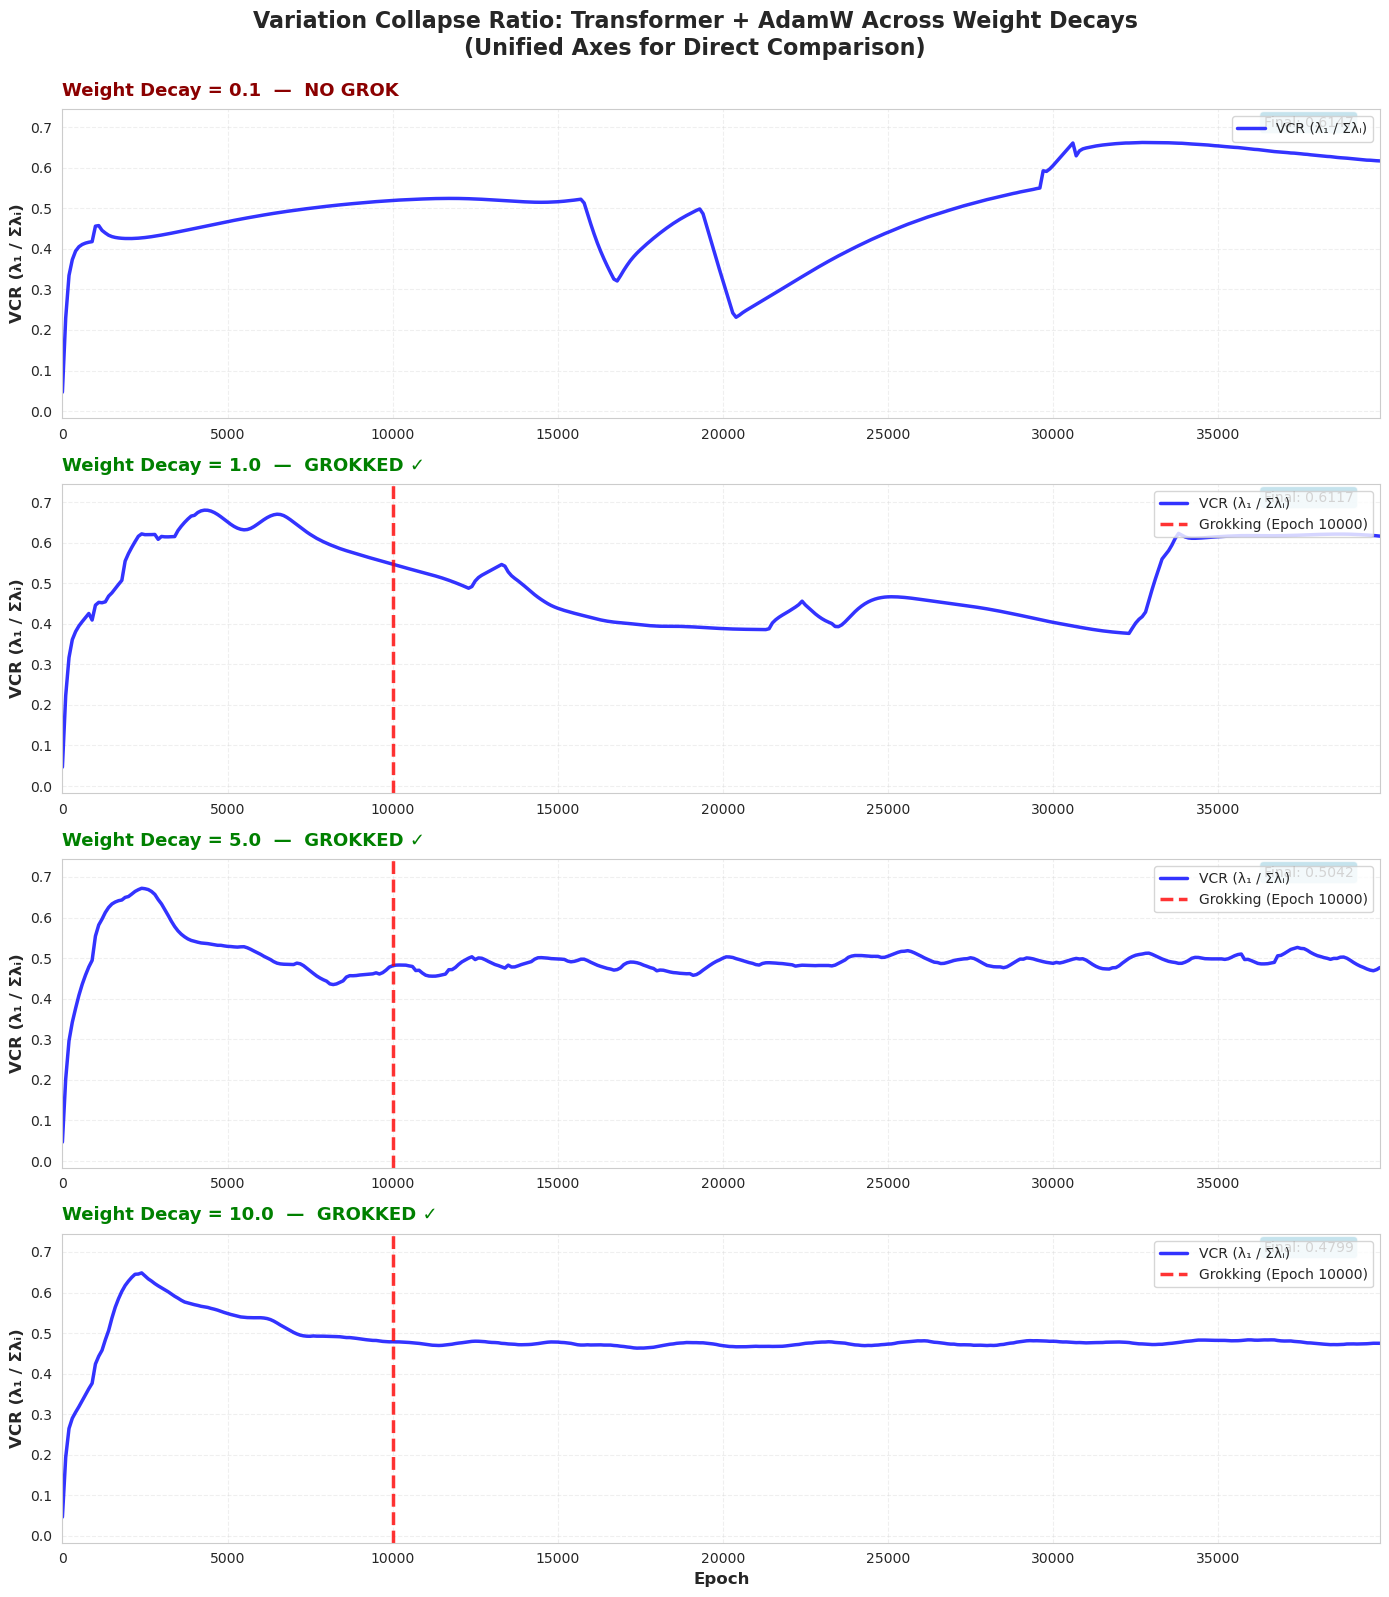

Generated panel for Variation Collapse Ratio (unified axes, vertical layout)


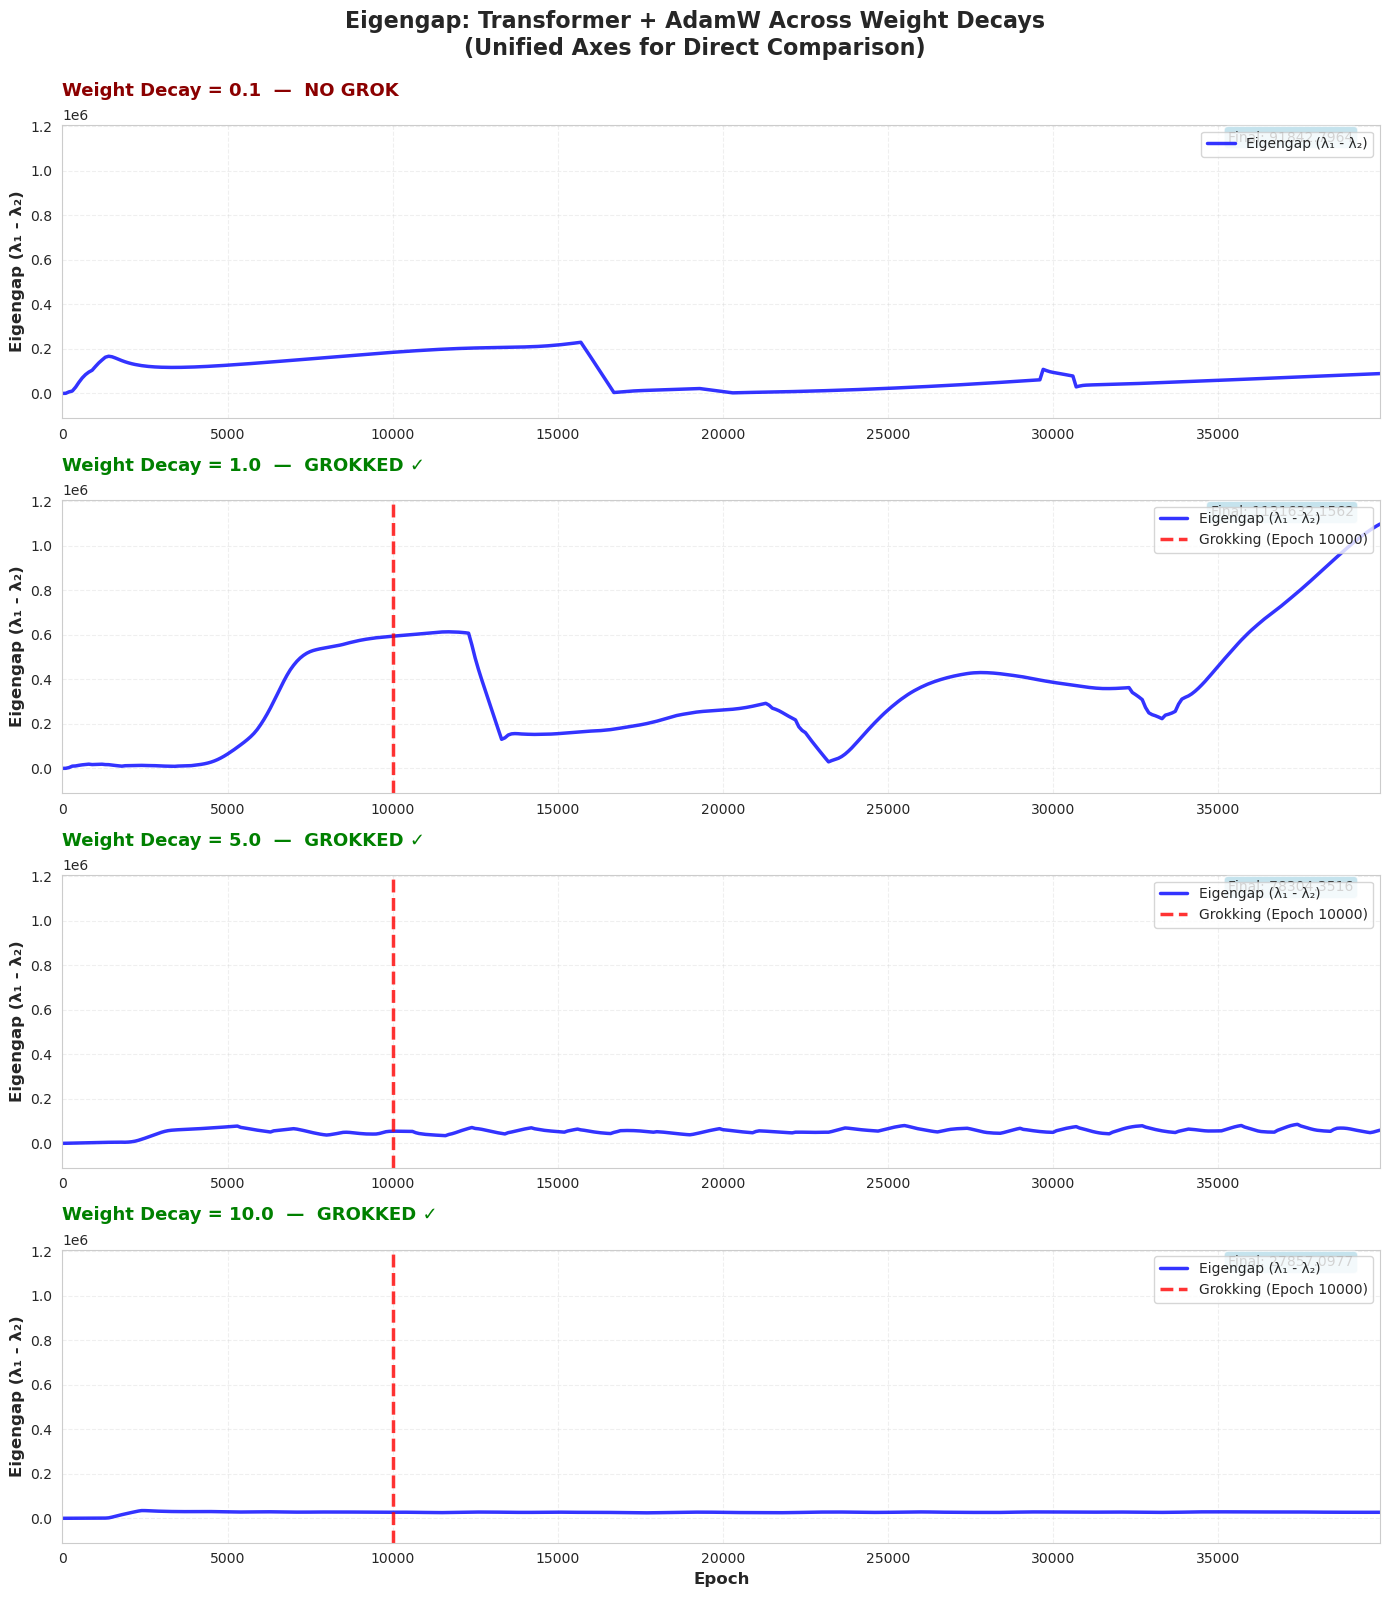

Generated panel for Eigengap (unified axes, vertical layout)


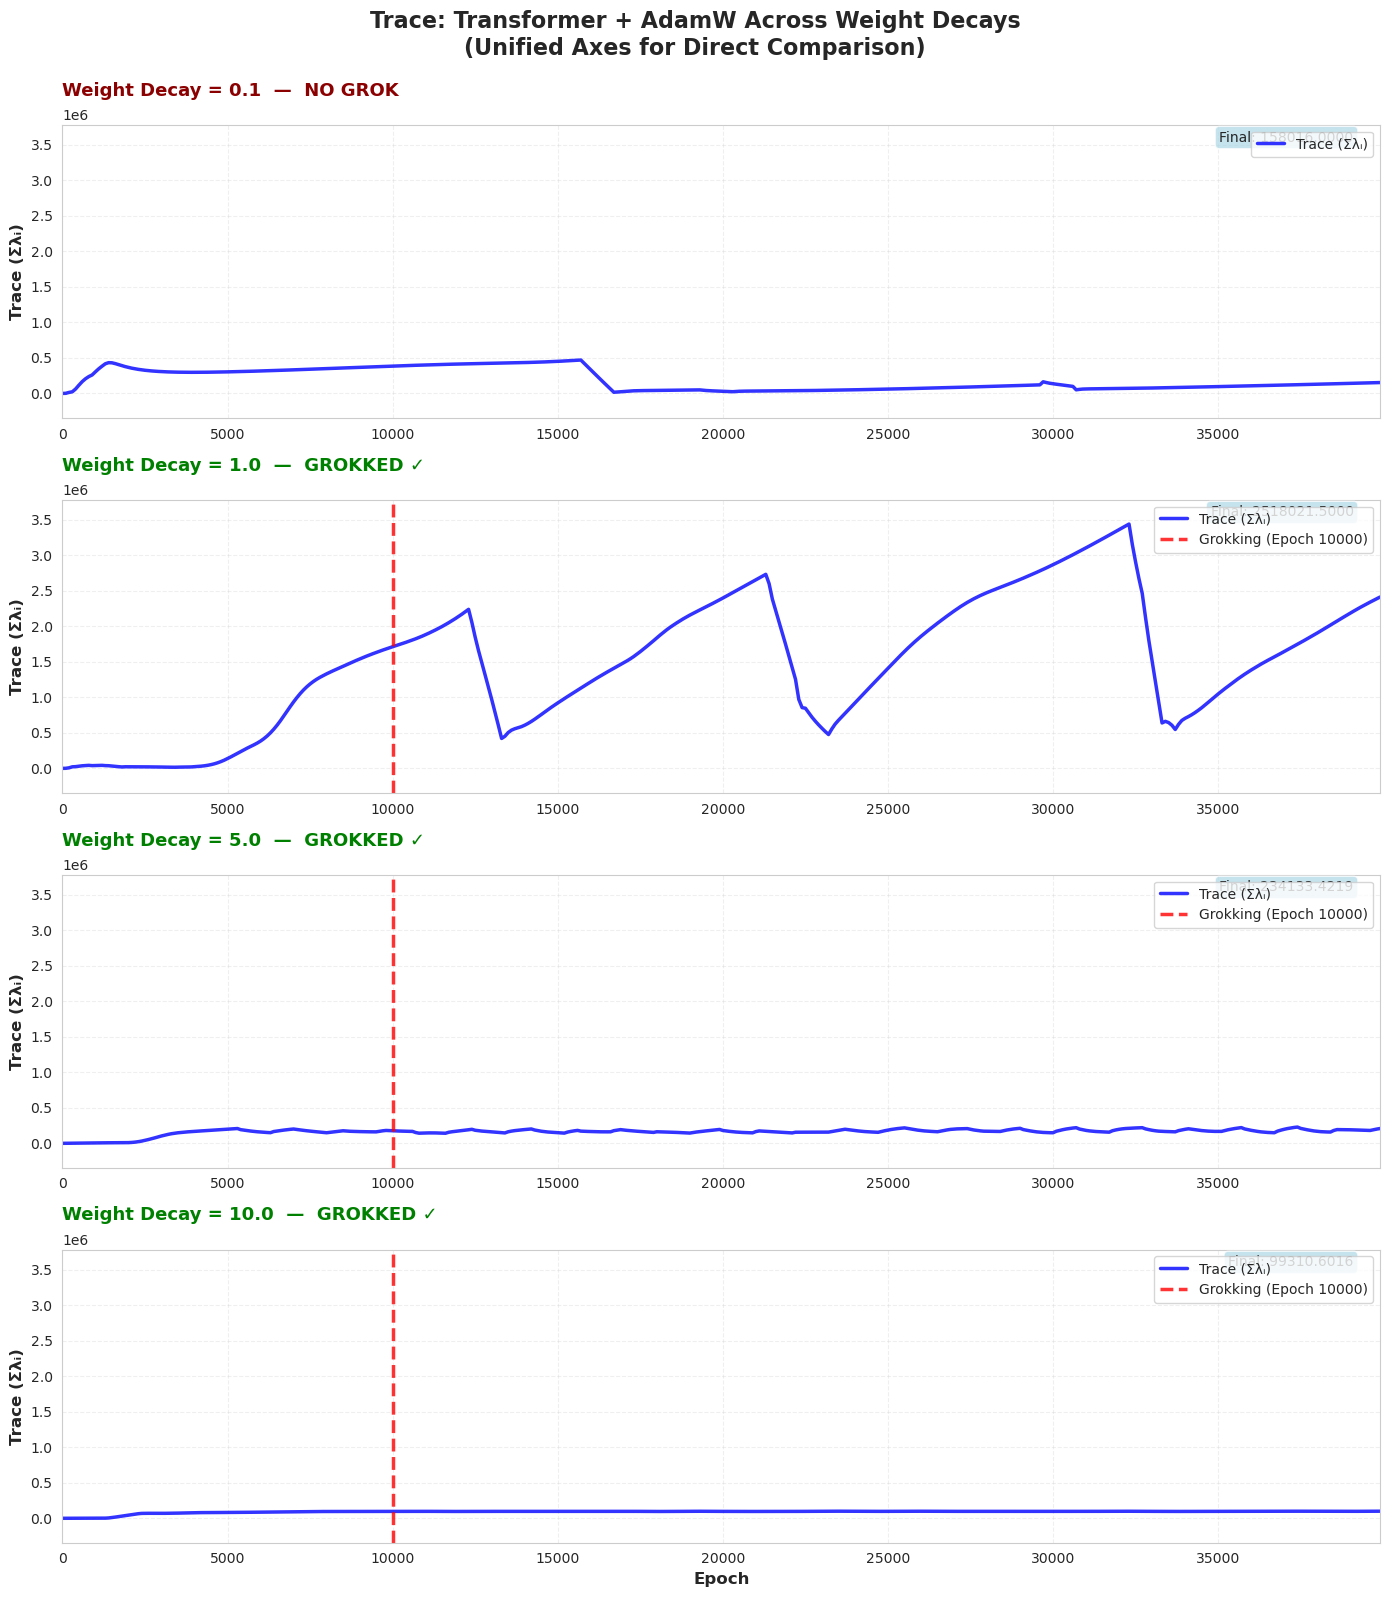

Generated panel for Trace (unified axes, vertical layout)


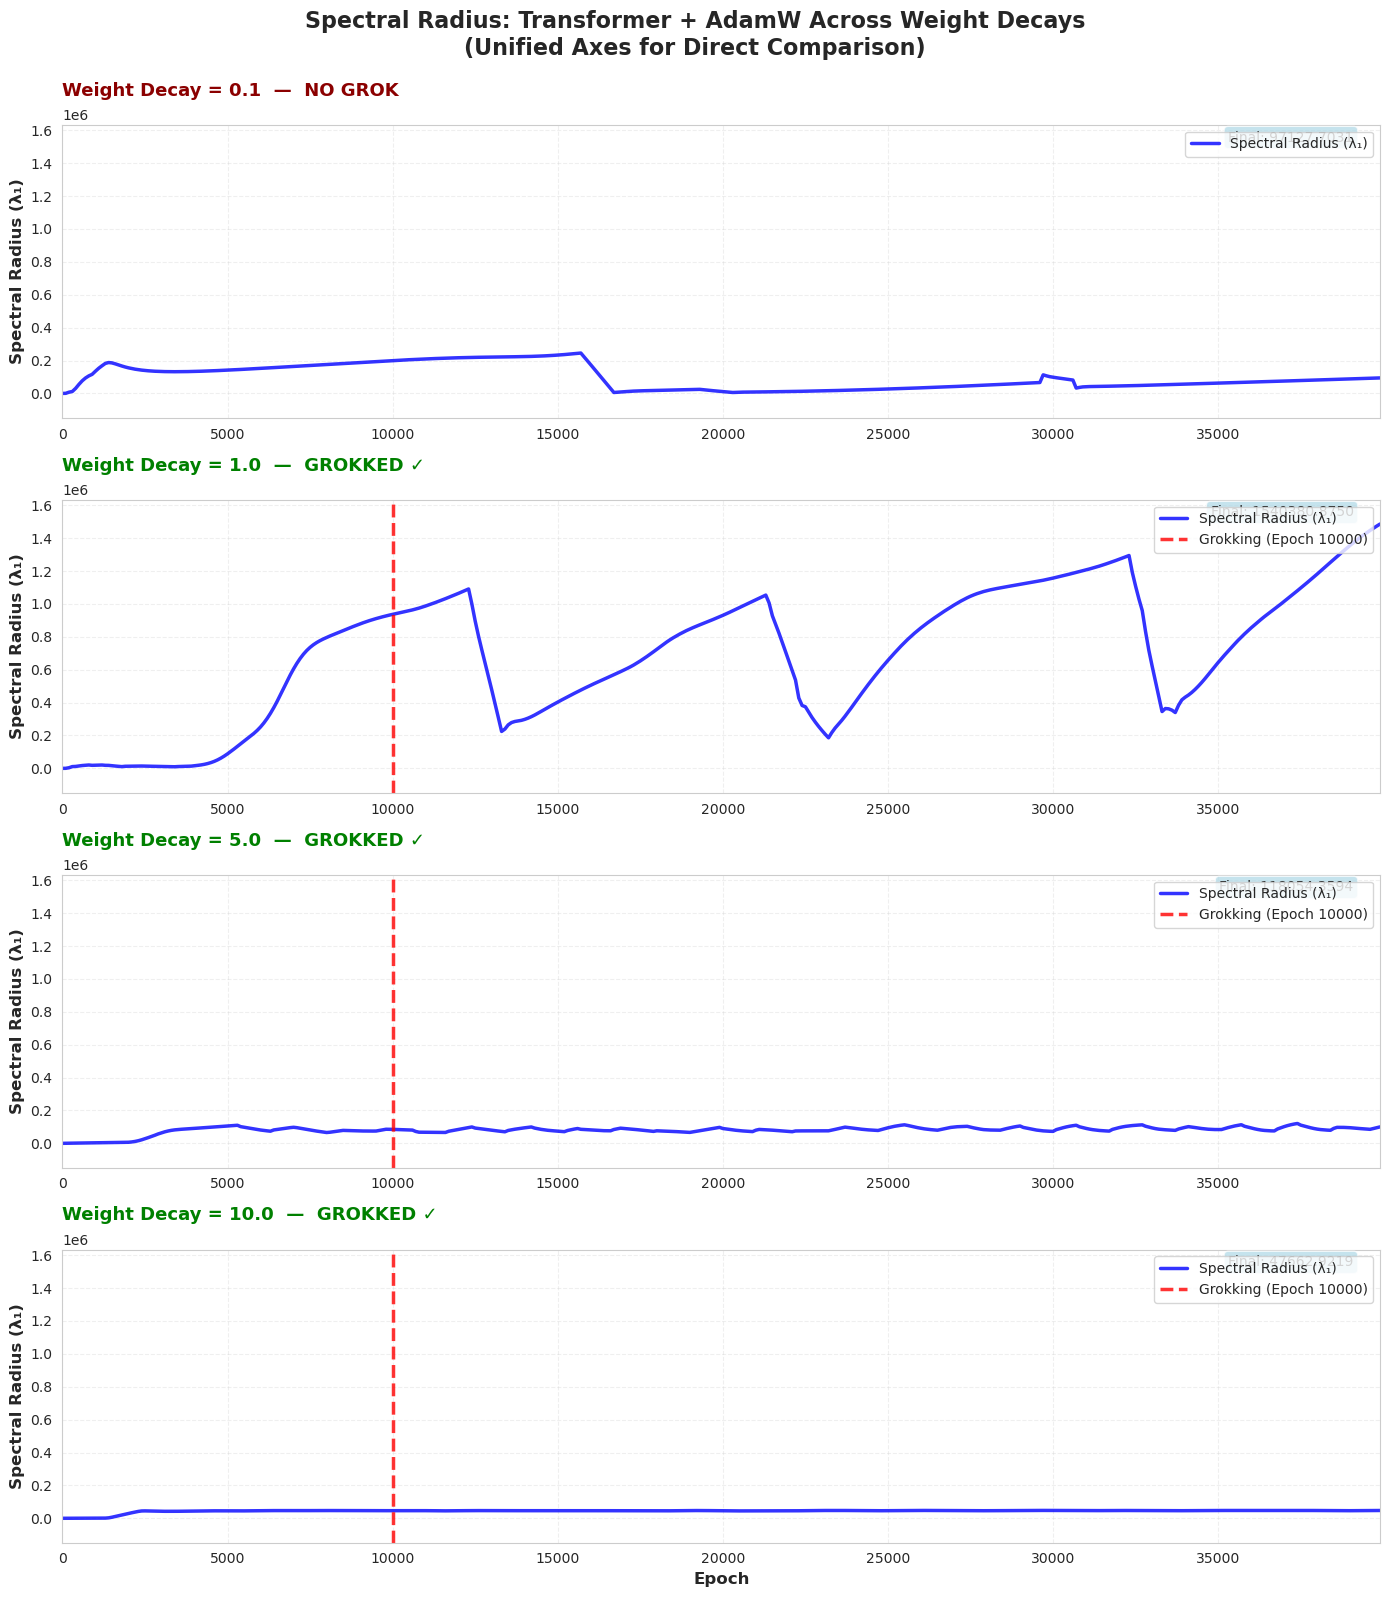

Generated panel for Spectral Radius (unified axes, vertical layout)

Generated 4 AGOP metric comparison panels


In [28]:
# AGOP metrics to analyze
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)', 'Variation Collapse Ratio'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)', 'Eigengap'),
    ('agop_trace', 'Trace (Σλᵢ)', 'Trace'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)', 'Spectral Radius'),
]

# Get sorted Transformer + AdamW experiments
transformer_adamw_sorted = sorted(transformer_adamw_exps.items(), 
                                  key=lambda x: x[1]['config'].get('weight_decay', 0))

print(f"Analyzing AGOP metrics for {len(transformer_adamw_sorted)} Transformer + AdamW experiments")

# Create a figure for each metric with 4 subplots stacked vertically
for metric_name, metric_label, metric_title in agop_metrics:
    # First pass: collect all data to determine unified axis ranges
    all_data = []
    max_epochs = 0
    
    for idx, (exp_name, exp_data) in enumerate(transformer_adamw_sorted):
        if idx >= 4:  # Only show 4 weight decay values
            break
        
        history = exp_data['history']
        config = exp_data['config']
        
        if metric_name not in history:
            continue
        
        epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
        metric_values = np.array(history[metric_name])
        
        min_len = min(len(epochs), len(metric_values))
        epochs = epochs[:min_len]
        metric_values = metric_values[:min_len]
        
        # Get grokking info
        if 'test_acc' in history and 'train_acc' in history:
            train_acc = np.array(history['train_acc'])[:min_len]
            test_acc = np.array(history['test_acc'])[:min_len]
            grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
            grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        else:
            grok_epoch = None
        
        metric_smooth = smooth_series(metric_values, window=10)
        
        all_data.append({
            'exp_name': exp_name,
            'config': config,
            'epochs': epochs,
            'metric_values': metric_values,
            'metric_smooth': metric_smooth,
            'grok_epoch': grok_epoch
        })
        
        max_epochs = max(max_epochs, epochs[-1] if len(epochs) > 0 else 0)
    
    if not all_data:
        print(f"No data available for {metric_title}, skipping...")
        continue
    
    # Determine unified y-axis range
    all_smooth_values = np.concatenate([d['metric_smooth'] for d in all_data])
    y_min = np.min(all_smooth_values)
    y_max = np.max(all_smooth_values)
    y_margin = (y_max - y_min) * 0.1
    y_lim = [y_min - y_margin, y_max + y_margin]
    
    # Create vertically stacked subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 16))
    
    for idx, data_dict in enumerate(all_data):
        ax = axes[idx]
        
        epochs = data_dict['epochs']
        metric_smooth = data_dict['metric_smooth']
        metric_values = data_dict['metric_values']
        grok_epoch = data_dict['grok_epoch']
        config = data_dict['config']
        wd = config.get('weight_decay', 0)
        
        # Plot the metric
        ax.plot(epochs, metric_smooth, linewidth=2.5, color='blue', alpha=0.8, label=metric_label)
        
        # Mark grokking epoch if it exists
        if grok_epoch is not None:
            ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2.5, alpha=0.8, 
                      label=f'Grokking (Epoch {grok_epoch})')
            status = "GROKKED ✓"
            title_color = 'green'
        else:
            status = "NO GROK"
            title_color = 'darkred'
        
        # Formatting with unified axes
        ax.set_ylabel(metric_label, fontsize=12, fontweight='bold')
        ax.set_title(f'Weight Decay = {wd}  —  {status}', 
                    fontsize=13, fontweight='bold', color=title_color, pad=10, loc='left')
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(alpha=0.3, linestyle='--')
        
        # Set unified axis limits
        ax.set_xlim([0, max_epochs])
        ax.set_ylim(y_lim)
        
        # Only show x-label on bottom plot
        if idx == len(all_data) - 1:
            ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        else:
            ax.set_xlabel('')
        
        # Add value annotations
        final_value = metric_values[-1]
        ax.text(0.98, 0.98, f'Final: {final_value:.4f}', 
               transform=ax.transAxes, fontsize=10, verticalalignment='top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    # Overall title
    fig.suptitle(f'{metric_title}: Transformer + AdamW Across Weight Decays\n(Unified Axes for Direct Comparison)', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    safe_metric_name = metric_name.replace('_', '-')
    plt.savefig(FIGURES_DIR / f'transformer_adamw_{safe_metric_name}_comparison.png', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Generated panel for {metric_title} (unified axes, vertical layout)")

print(f"\n{'='*80}")
print(f"Generated {len(agop_metrics)} AGOP metric comparison panels")
print(f"{'='*80}")


### AGOP Metrics with Overlaid Train/Test Accuracy

Now let's overlay normalized train and test accuracy on the AGOP metrics to see how they co-evolve.
All three signals (AGOP metric, train accuracy, test accuracy) are normalized to [0, 1] range for comparison.


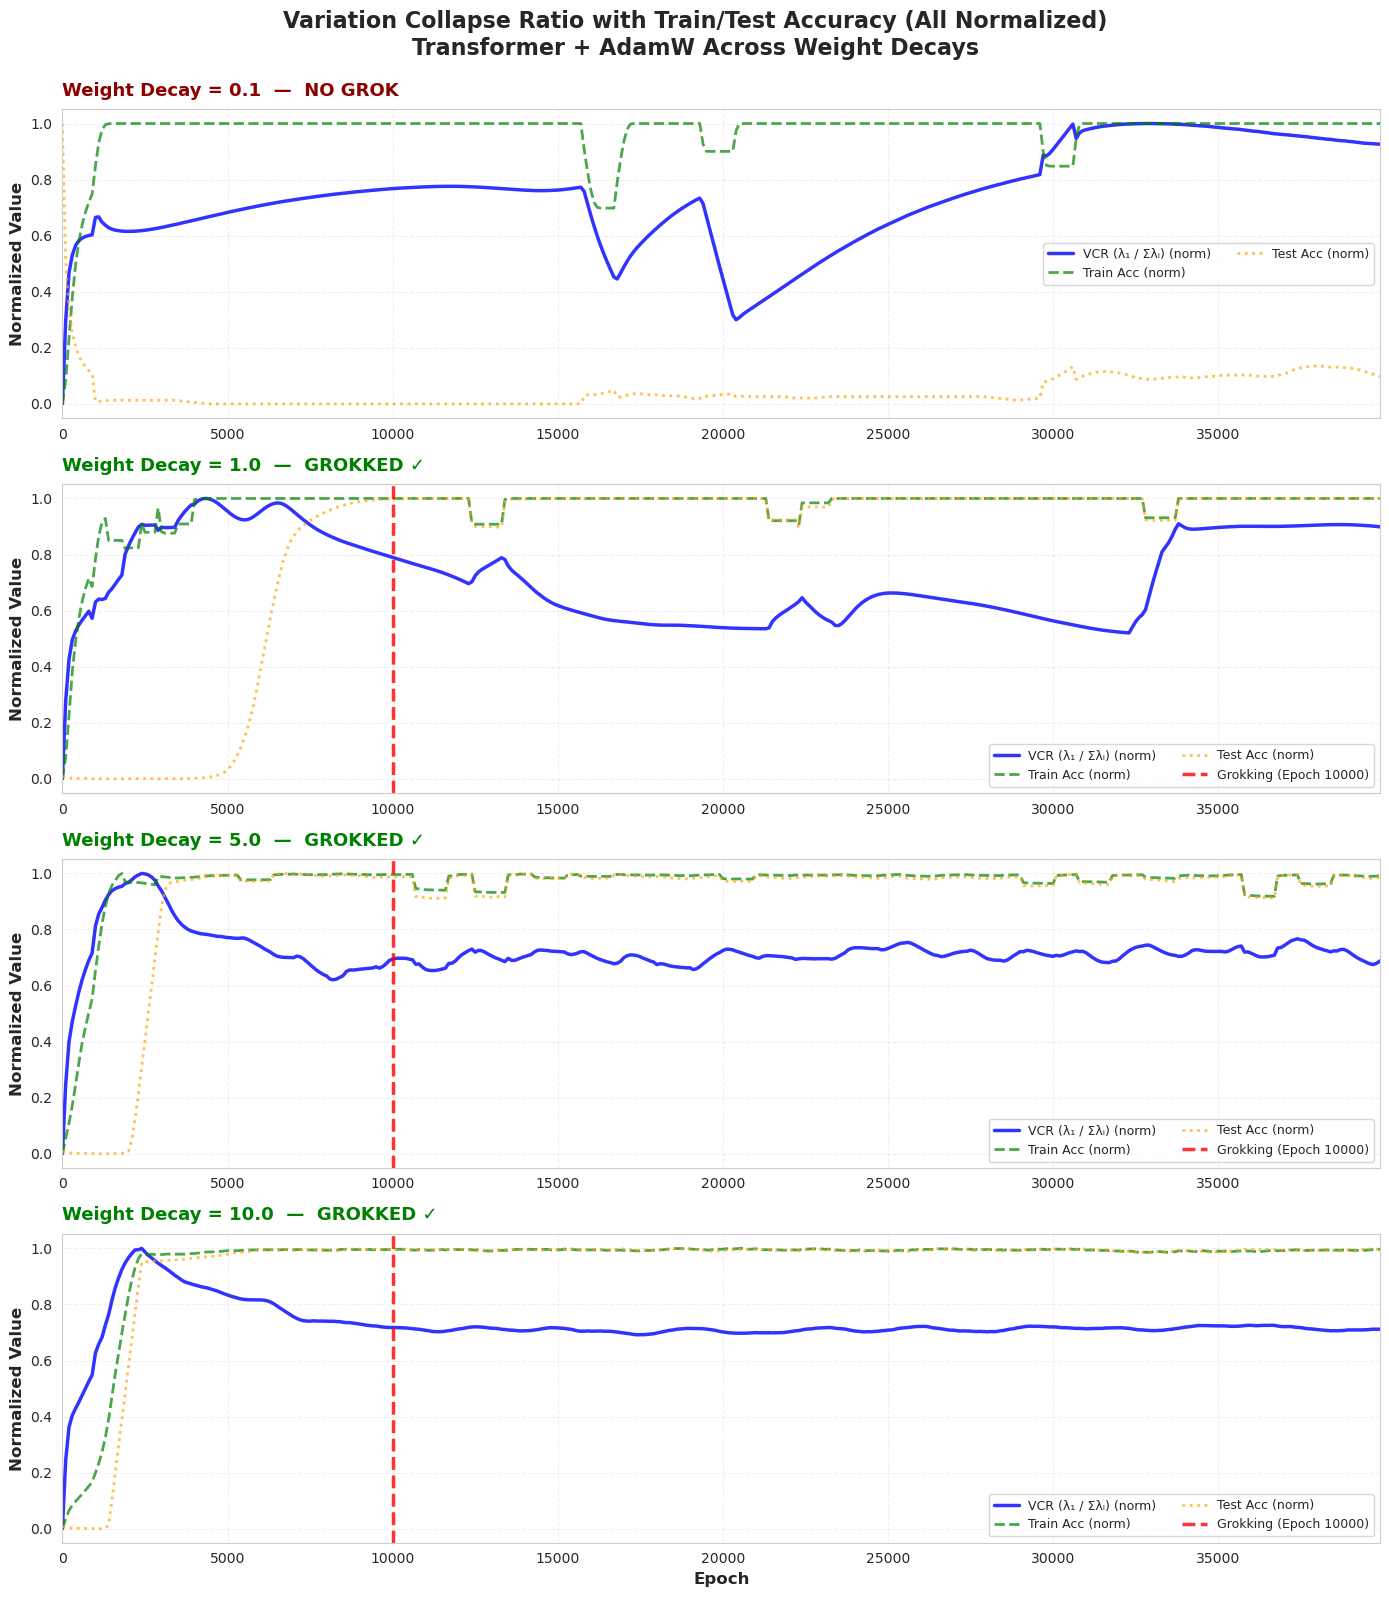

Generated overlay panel for Variation Collapse Ratio


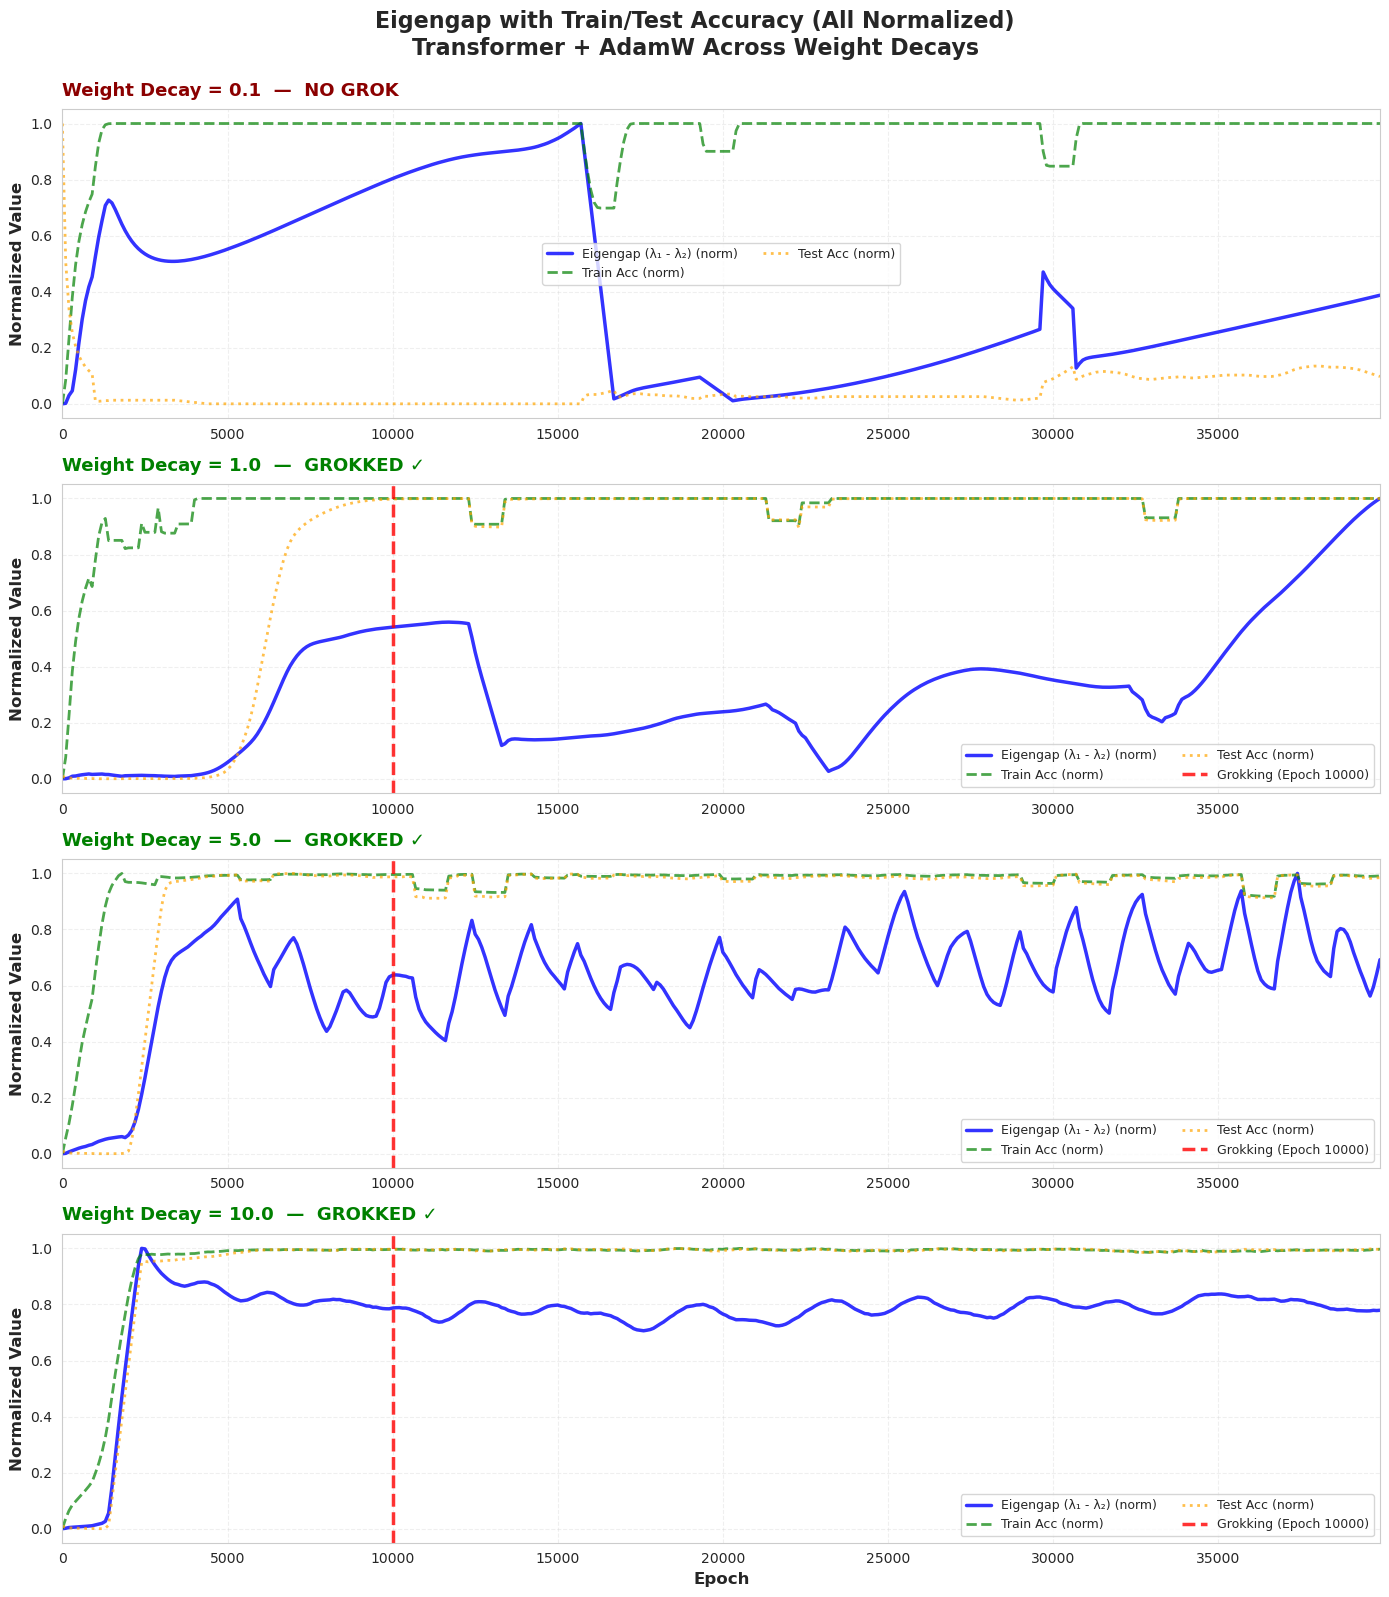

Generated overlay panel for Eigengap


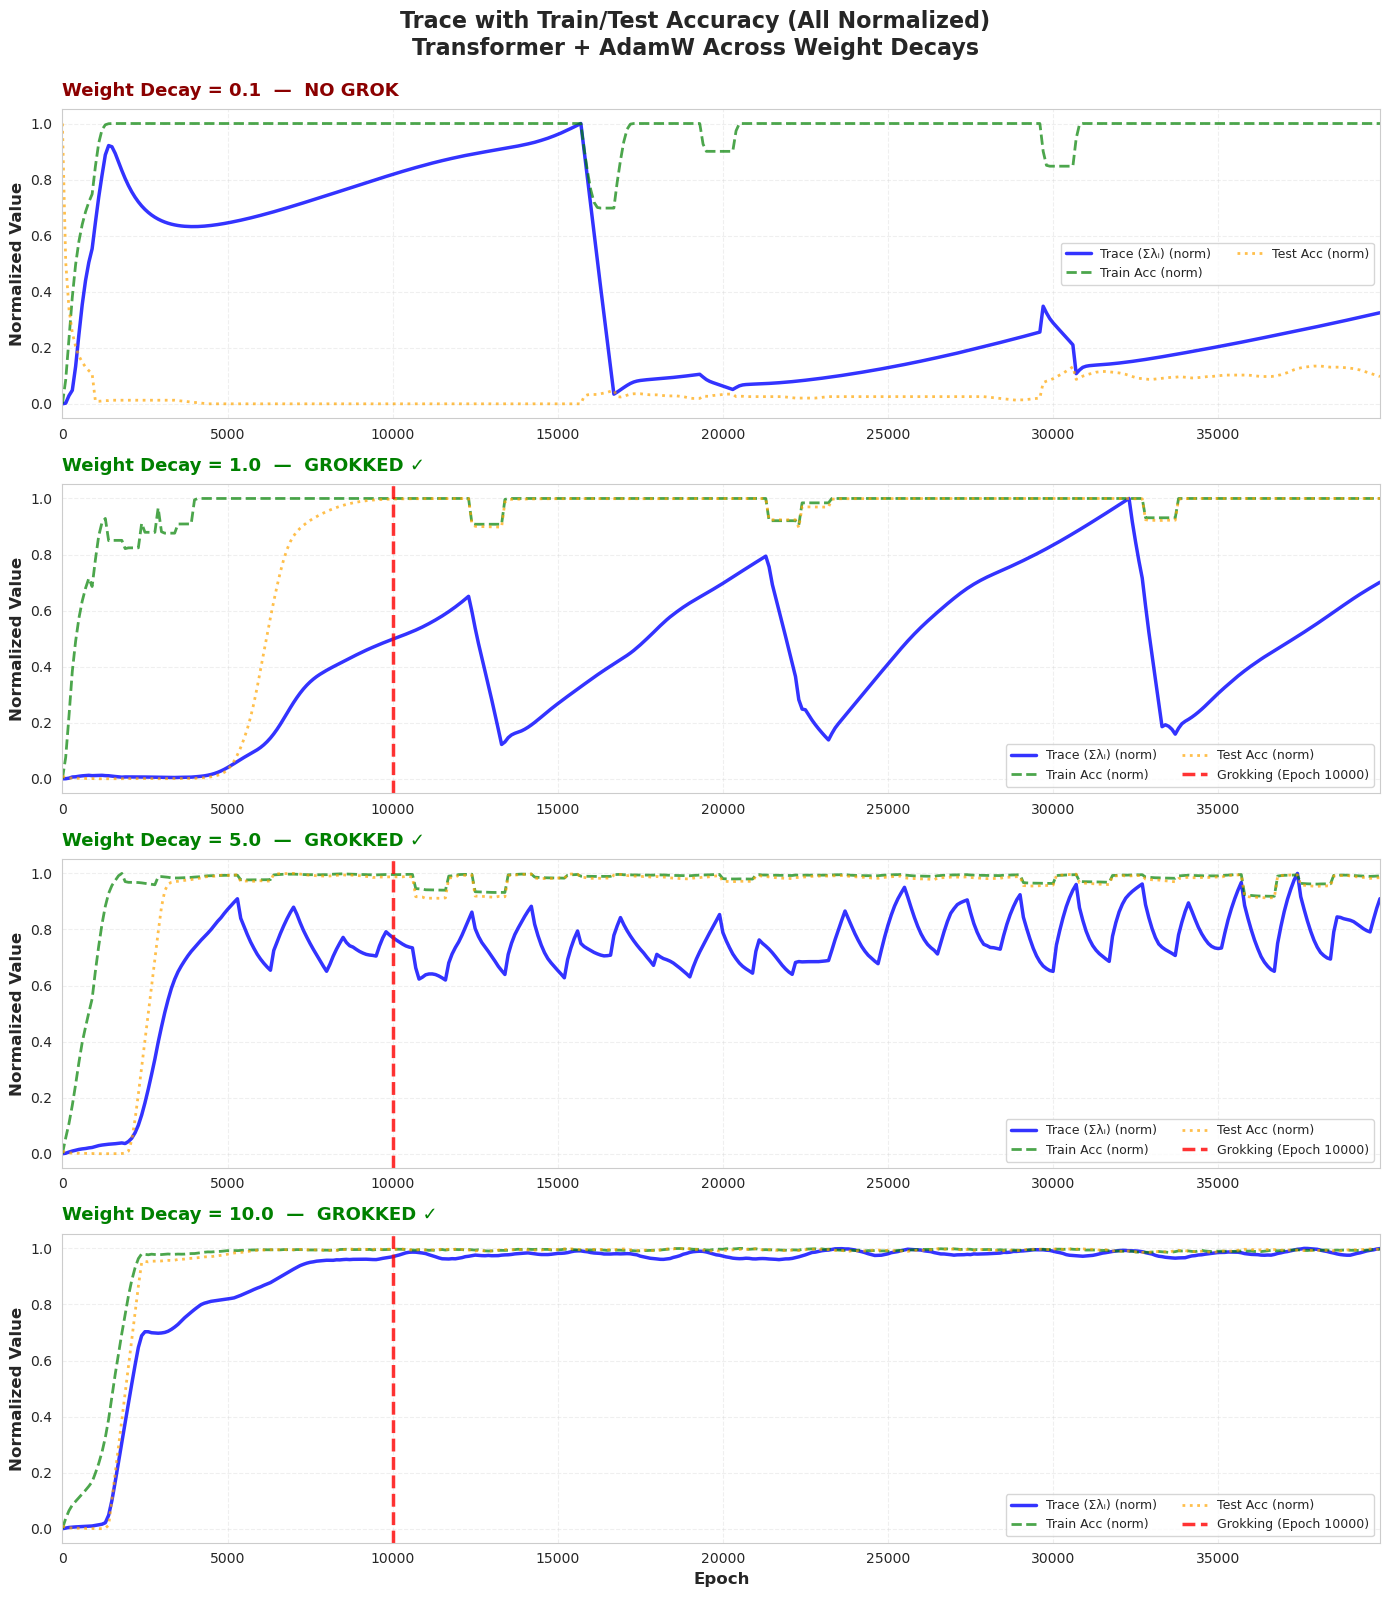

Generated overlay panel for Trace


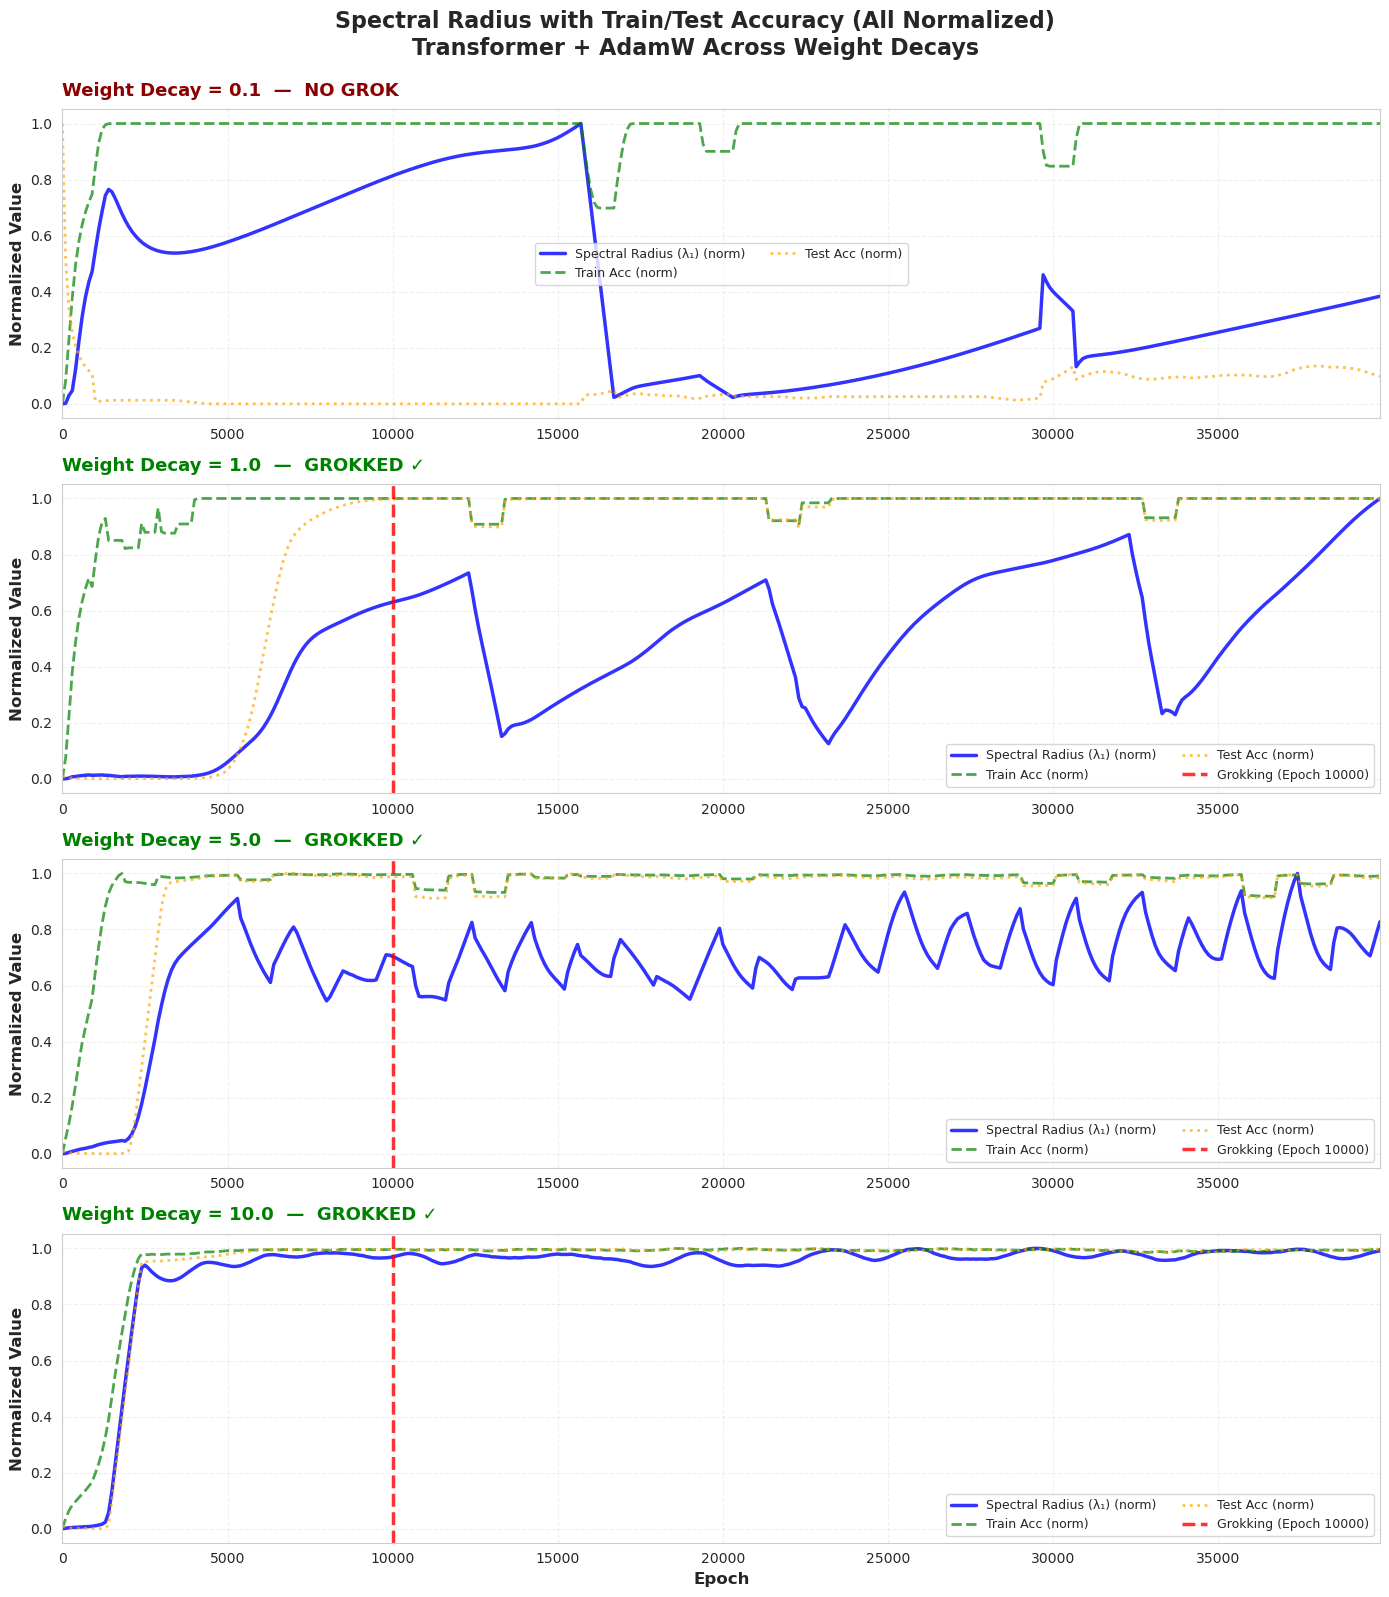

Generated overlay panel for Spectral Radius

Generated 4 AGOP metric overlay panels
All values normalized to [0, 1] for direct comparison


In [29]:
def normalize_series(series):
    """Normalize a series to [0, 1] range using min-max normalization."""
    s_min = np.min(series)
    s_max = np.max(series)
    if s_max - s_min < 1e-10:  # Avoid division by zero
        return np.zeros_like(series)
    return (series - s_min) / (s_max - s_min)

# Create overlay plots for each AGOP metric
for metric_name, metric_label, metric_title in agop_metrics:
    # Collect all data
    all_data = []
    
    for idx, (exp_name, exp_data) in enumerate(transformer_adamw_sorted):
        if idx >= 4:  # Only show 4 weight decay values
            break
        
        history = exp_data['history']
        config = exp_data['config']
        
        # Check if all required data exists
        if metric_name not in history or 'train_acc' not in history or 'test_acc' not in history:
            continue
        
        epochs = np.array(history.get('epoch', range(len(history.get('test_acc', [])))))
        metric_values = np.array(history[metric_name])
        train_acc = np.array(history['train_acc'])
        test_acc = np.array(history['test_acc'])
        
        # Align lengths
        min_len = min(len(epochs), len(metric_values), len(train_acc), len(test_acc))
        epochs = epochs[:min_len]
        metric_values = metric_values[:min_len]
        train_acc = train_acc[:min_len]
        test_acc = test_acc[:min_len]
        
        # Detect grokking
        grok_epoch_idx = detect_grokking_epoch(train_acc, test_acc)
        grok_epoch = epochs[grok_epoch_idx] if grok_epoch_idx is not None else None
        
        # Smooth and normalize
        metric_smooth = smooth_series(metric_values, window=10)
        train_smooth = smooth_series(train_acc, window=10)
        test_smooth = smooth_series(test_acc, window=10)
        
        metric_norm = normalize_series(metric_smooth)
        train_norm = normalize_series(train_smooth)
        test_norm = normalize_series(test_smooth)
        
        all_data.append({
            'exp_name': exp_name,
            'config': config,
            'epochs': epochs,
            'metric_norm': metric_norm,
            'train_norm': train_norm,
            'test_norm': test_norm,
            'grok_epoch': grok_epoch
        })
    
    if not all_data:
        print(f"No data available for {metric_title} overlay, skipping...")
        continue
    
    max_epochs = max([d['epochs'][-1] for d in all_data if len(d['epochs']) > 0])
    
    # Create vertically stacked subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 16))
    
    for idx, data_dict in enumerate(all_data):
        ax = axes[idx]
        
        epochs = data_dict['epochs']
        metric_norm = data_dict['metric_norm']
        train_norm = data_dict['train_norm']
        test_norm = data_dict['test_norm']
        grok_epoch = data_dict['grok_epoch']
        config = data_dict['config']
        wd = config.get('weight_decay', 0)
        
        # Plot all three normalized signals
        ax.plot(epochs, metric_norm, linewidth=2.5, color='blue', alpha=0.8, 
               label=f'{metric_label} (norm)', linestyle='-')
        ax.plot(epochs, train_norm, linewidth=2.0, color='green', alpha=0.7, 
               label='Train Acc (norm)', linestyle='--')
        ax.plot(epochs, test_norm, linewidth=2.0, color='orange', alpha=0.7, 
               label='Test Acc (norm)', linestyle=':')
        
        # Mark grokking epoch if it exists
        if grok_epoch is not None:
            ax.axvline(x=grok_epoch, color='red', linestyle='--', linewidth=2.5, alpha=0.8, 
                      label=f'Grokking (Epoch {grok_epoch})')
            status = "GROKKED ✓"
            title_color = 'green'
        else:
            status = "NO GROK"
            title_color = 'darkred'
        
        # Formatting with unified axes
        ax.set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
        ax.set_title(f'Weight Decay = {wd}  —  {status}', 
                    fontsize=13, fontweight='bold', color=title_color, pad=10, loc='left')
        ax.legend(fontsize=9, loc='best', ncol=2)
        ax.grid(alpha=0.3, linestyle='--')
        
        # Set unified axis limits
        ax.set_xlim([0, max_epochs])
        ax.set_ylim([-0.05, 1.05])
        
        # Only show x-label on bottom plot
        if idx == len(all_data) - 1:
            ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        else:
            ax.set_xlabel('')
    
    # Overall title
    fig.suptitle(f'{metric_title} with Train/Test Accuracy (All Normalized)\nTransformer + AdamW Across Weight Decays', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    safe_metric_name = metric_name.replace('_', '-')
    plt.savefig(FIGURES_DIR / f'transformer_adamw_{safe_metric_name}_with_accuracy_overlay.png', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Generated overlay panel for {metric_title}")

print(f"\n{'='*80}")
print(f"Generated {len(agop_metrics)} AGOP metric overlay panels")
print(f"All values normalized to [0, 1] for direct comparison")
print(f"{'='*80}")


### Interpreting AGOP Metrics

**What to look for in the plots above:**

1. **Variation Collapse Ratio (VCR)**: 
   - Measures how much variance is captured by the top eigenvalue
   - Higher VCR → more "collapsed" representation (lower dimensional)
   - During grokking, VCR may show sudden changes as the network reorganizes its representations

2. **Eigengap**: 
   - Difference between top two eigenvalues (λ₁ - λ₂)
   - Large eigengap → strong dominance of first principal component
   - May indicate transition from distributed to more structured representations

3. **Trace**: 
   - Sum of all eigenvalues (total variance in activations)
   - Reflects overall "energy" or magnitude of representations
   - Weight decay should generally decrease trace over time

4. **Spectral Radius**: 
   - Largest eigenvalue (λ₁)
   - Governs gradient flow and stability
   - Sudden changes may correlate with phase transitions in learning

**Expected patterns for grokking vs non-grokking:**
- Grokking experiments may show **discontinuities or inflection points** in AGOP metrics around the grokking epoch
- Non-grokking experiments likely show **smoother, monotonic evolution**
- Weight decay should affect the **magnitude and dynamics** of these metrics


---
# Section A: Optimizer Comparison

Compare performance of AdamW, Muon, and SGD optimizers within each architecture.

## A1: MLP Architecture - Optimizer Comparison

In [20]:
# Filter MLP experiments
mlp_exps = filter_experiments(experiments, architecture='mlp')
mlp_df = summary_df[summary_df['architecture'] == 'mlp'].copy()

print(f"MLP Experiments: {len(mlp_exps)}")
print(f"\nPerformance by Optimizer and Weight Decay:")
print(f"="*80)

# Create pivot table
mlp_pivot = mlp_df.pivot_table(
    values=['final_test_acc', 'grokked', 'grok_epoch'],
    index='optimizer',
    columns='weight_decay',
    aggfunc={'final_test_acc': 'mean', 'grokked': 'sum', 'grok_epoch': lambda x: x.max() if any(x > 0) else -1}
)

display(mlp_pivot)

MLP Experiments: 12

Performance by Optimizer and Weight Decay:


final_test_acc                               grok_epoch         \
weight_decay           0.1       1.0       5.0       10.0       0.1    1.0    
optimizer                                                                     
adamw              0.006488  0.962748  0.001454  0.000112         -1  32900   
muon               0.000336  0.000112  0.031547  0.247343         -1     -1   
sgd                0.007719  0.007719  0.007719  0.007719         -1     -1   

                       grokked                 
weight_decay 5.0  10.0    0.1  1.0  5.0  10.0  
optimizer                                      
adamw          -1   -1       0    1    0    0  
muon           -1   -1       0    0    0    0  
sgd            -1   -1       0    0    0    0

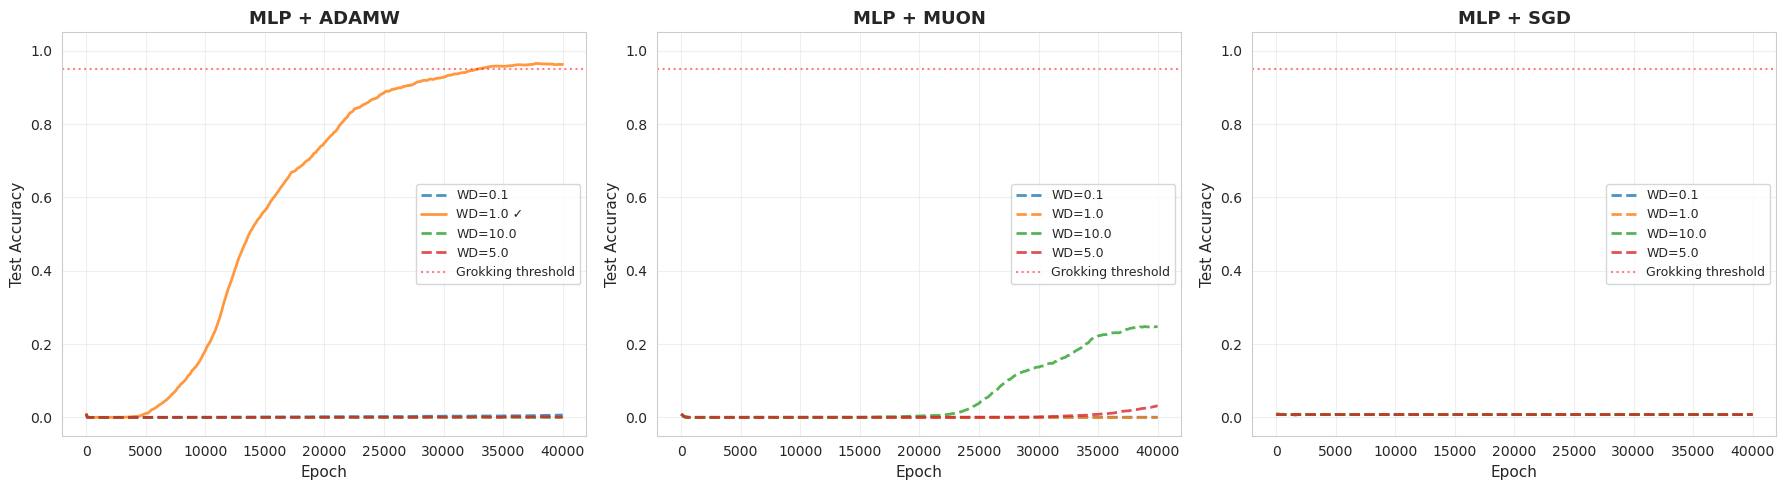

Saved figure: mlp_optimizer_comparison.png


In [21]:
# Plot test accuracy curves for MLP by optimizer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
optimizers = ['adamw', 'muon', 'sgd']

for idx, opt in enumerate(optimizers):
    ax = axes[idx]
    opt_exps = filter_experiments(mlp_exps, optimizer=opt)
    
    for exp_name, exp_data in opt_exps.items():
        history = exp_data['history']
        config = exp_data['config']
        
        if 'test_acc' not in history:
            continue
            
        epochs = np.array(history.get('epoch', range(len(history['test_acc']))))
        test_acc = np.array(history['test_acc'])
        wd = config.get('weight_decay', 0)
        
        grokked = classify_grokking(exp_data)
        linestyle = '-' if grokked else '--'
        label = f"WD={wd}" + (" ✓" if grokked else "")
        
        ax.plot(epochs, test_acc, linestyle=linestyle, linewidth=2, label=label, alpha=0.8)
    
    ax.axhline(y=0.95, color='r', linestyle=':', alpha=0.5, label='Grokking threshold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Test Accuracy', fontsize=11)
    ax.set_title(f'MLP + {opt.upper()}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mlp_optimizer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: mlp_optimizer_comparison.png")

## A2: Transformer Architecture - Optimizer Comparison

In [26]:
# Filter Transformer experiments
trans_exps = filter_experiments(experiments, architecture='transformer')
trans_df = summary_df[summary_df['architecture'] == 'transformer'].copy()

print(f"Transformer Experiments: {len(trans_exps)}")
print(f"\nPerformance by Optimizer and Weight Decay:")
print(f"="*80)

# Create pivot table
trans_pivot = trans_df.pivot_table(
    values=['final_test_acc', 'grokked', 'grok_epoch'],
    index='optimizer',
    columns='weight_decay',
    aggfunc={'final_test_acc': 'mean', 'grokked': 'sum', 'grok_epoch': lambda x: x.max() if any(x > 0) else -1}
)

display(trans_pivot)

Transformer Experiments: 12

Performance by Optimizer and Weight Decay:


final_test_acc                               grok_epoch        \
weight_decay           0.1       1.0       5.0       10.0       0.1   1.0    
optimizer                                                                    
adamw              0.000783  1.000000  0.921468  0.940933         -1  7500   
muon               0.001342  0.000000  0.000000  0.000000         -1    -1   
sgd                0.007719  0.008614  0.008614  0.008614         -1    -1   

                       grokked                 
weight_decay 5.0  10.0    0.1  1.0  5.0  10.0  
optimizer                                      
adamw          -1   -1       0    1    0    0  
muon           -1   -1       0    0    0    0  
sgd            -1   -1       0    0    0    0

---
# Section B: Weight Decay Comparison

Analyze the effect of weight decay on grokking within each optimizer.

---
# Section C: AGOP Metrics Analysis

Analyze AGOP metric evolution and relationship to grokking.

## C1: Grokking vs Non-Grokking - AGOP Comparison

In [23]:
# Separate grokking and non-grokking experiments
grok_exps = {name: data for name, data in experiments.items() if classify_grokking(data)}
nogrok_exps = {name: data for name, data in experiments.items() if not classify_grokking(data)}

print(f"Grokking experiments: {len(grok_exps)}")
print(f"Non-grokking experiments: {len(nogrok_exps)}")
print(f"\nGrokking experiments:")
for name in grok_exps.keys():
    grok_epoch = compute_time_to_grok(grok_exps[name])
    print(f"  - {name}: grokked at epoch {grok_epoch}")

Grokking experiments: 2
Non-grokking experiments: 22

Grokking experiments:
  - nanda_mlp_adamw_wd1.0_seed42: grokked at epoch 32900
  - nanda_transformer_adamw_wd1.0_seed42: grokked at epoch 7500


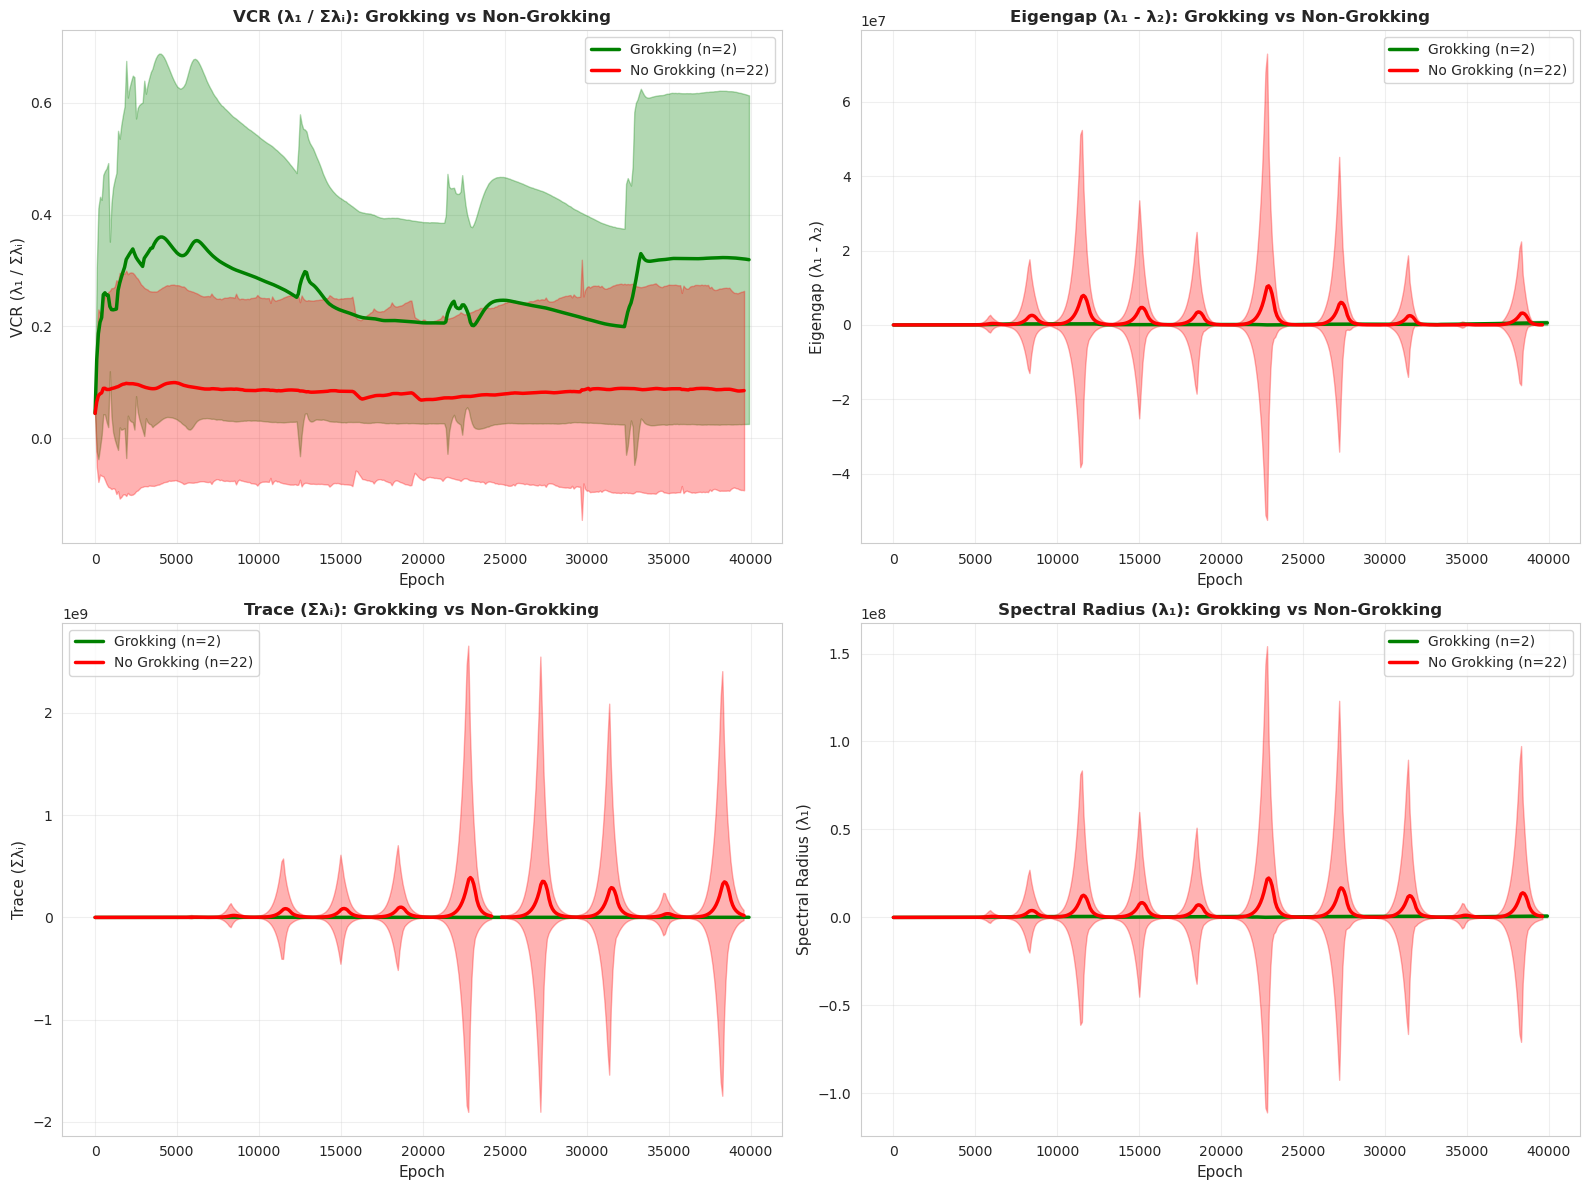

Saved figure: agop_grokking_vs_nogrokking.png


In [24]:
# Plot AGOP metrics: grokking vs non-grokking
agop_metrics = [
    ('agop_variation_collapse_ratio', 'VCR (λ₁ / Σλᵢ)'),
    ('agop_eigengap', 'Eigengap (λ₁ - λ₂)'),
    ('agop_trace', 'Trace (Σλᵢ)'),
    ('agop_spectral_radius', 'Spectral Radius (λ₁)'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (metric_name, metric_label) in enumerate(agop_metrics):
    ax = axes[idx]
    
    # Collect grokking data
    grok_data = []
    for exp_data in grok_exps.values():
        history = exp_data.get('history', {})
        if metric_name in history:
            grok_data.append(np.array(history[metric_name]))
    
    # Collect non-grokking data
    nogrok_data = []
    for exp_data in nogrok_exps.values():
        history = exp_data.get('history', {})
        if metric_name in history:
            nogrok_data.append(np.array(history[metric_name]))
    
    if grok_data:
        # Align lengths
        min_len = min(len(d) for d in grok_data)
        grok_aligned = np.array([d[:min_len] for d in grok_data])
        grok_mean = np.mean(grok_aligned, axis=0)
        grok_std = np.std(grok_aligned, axis=0)
        
        # Get epochs
        first_exp = list(grok_exps.values())[0]
        epochs = np.array(first_exp['history'].get('epoch', range(min_len)))[:min_len]
        
        # Smooth
        grok_mean_smooth = smooth_series(grok_mean, window=5)
        
        ax.plot(epochs, grok_mean_smooth, 'g-', linewidth=2.5, label=f'Grokking (n={len(grok_data)})')
        ax.fill_between(epochs, grok_mean_smooth - grok_std[:min_len], 
                        grok_mean_smooth + grok_std[:min_len], alpha=0.3, color='g')
    
    if nogrok_data:
        # Align lengths
        min_len = min(len(d) for d in nogrok_data)
        nogrok_aligned = np.array([d[:min_len] for d in nogrok_data])
        nogrok_mean = np.mean(nogrok_aligned, axis=0)
        nogrok_std = np.std(nogrok_aligned, axis=0)
        
        epochs = np.array(first_exp['history'].get('epoch', range(min_len)))[:min_len]
        
        # Smooth
        nogrok_mean_smooth = smooth_series(nogrok_mean, window=5)
        
        ax.plot(epochs, nogrok_mean_smooth, 'r-', linewidth=2.5, label=f'No Grokking (n={len(nogrok_data)})')
        ax.fill_between(epochs, nogrok_mean_smooth - nogrok_std[:min_len],
                        nogrok_mean_smooth + nogrok_std[:min_len], alpha=0.3, color='r')
    
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label}: Grokking vs Non-Grokking', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'agop_grokking_vs_nogrokking.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved figure: agop_grokking_vs_nogrokking.png")

---
# Summary and Key Findings

## Best Configurations
Based on the analysis above, identify the top performing configurations.

In [25]:
# Display top 5 experiments by final test accuracy
print(f"\nTop 5 Configurations by Final Test Accuracy:")
print(f"="*80)

top_df = summary_df.nlargest(5, 'final_test_acc')[[
    'experiment', 'architecture', 'optimizer', 'weight_decay', 
    'final_test_acc', 'grokked', 'grok_epoch'
]]

display(top_df)

# Summary statistics
print(f"\nKey Findings:")
print(f"-"*80)
print(f"1. Overall grokking rate: {grok_rate:.1f}%")
print(f"2. Best architecture: {summary_df.groupby('architecture')['final_test_acc'].mean().idxmax()}")
print(f"3. Best optimizer: {summary_df.groupby('optimizer')['final_test_acc'].mean().idxmax()}")

print(f"\nAnalysis complete! All figures saved to: {FIGURES_DIR.absolute()}")


Top 5 Configurations by Final Test Accuracy:


,experiment,architecture,optimizer,weight_decay,final_test_acc,grokked,grok_epoch
13,nanda_transformer_adamw_wd1.0_seed42,transformer,adamw,1.0,1.000000,True,7500
1,nanda_mlp_adamw_wd1.0_seed42,mlp,adamw,1.0,0.962748,True,32900
14,nanda_transformer_adamw_wd10.0_seed42,transformer,adamw,10.0,0.940933,False,-1
15,nanda_transformer_adamw_wd5.0_seed42,transformer,adamw,5.0,0.921468,False,-1
6,nanda_mlp_muon_wd10.0_seed42,mlp,muon,10.0,0.247343,False,-1



Key Findings:
--------------------------------------------------------------------------------
1. Overall grokking rate: 8.3%
2. Best architecture: transformer
3. Best optimizer: adamw

Analysis complete! All figures saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/agop_experiments/analysis/figures/nanda
